# Machine Learning–Based Prediction of Capital Bikeshare Usage in Washington, D.C.


## Table of Content

- [1. Introduction](#1-introduction)
- [2. Methodology](#2-methodology)
  - [2.1 Data Preprocessing](#21-data-preprocessing)
  - [2.2 Data Analysis](#22-data-analysis)
- [3. Modelling and Optimization](#3-modelling-and-Optimization)
  - [3.1 Linear Regression](#31-Linear-Regression)
  - [3.2 Ridge Regression](#32-Ridge-Regression)
  - [3.3 LASSO Regression](#33-LASSO-Regression)
  - [3.4 Random Forest Regression](#34-Random-Forest-Regression)
- [4. Evaluation](#4-evaluation)
- [5. Conclusion and Future Work](#5-conclusion-and-future-work)
- [6. Sources](#6-Sources)

## 1. Introduction



In recent years, bike‑sharing systems have become an increasingly popular, eco‑friendly urban mobility solution. By allowing users to pick up and drop off bicycles at automated stations throughout a city, these systems help reduce traffic congestion, lower carbon emissions, and promote healthy lifestyles.   Beyond their real‑world applications, the unique properties of data generated by bike‑sharing systems also make them highly valuable for research. Effectively managing a bike‑sharing network requires accurate demand forecasting. Operators need to know how many bikes will be rented on any given day in order to redistribute fleets, schedule maintenance and ensure availability.

To accomplish this, this project will focus on modelling and prediction of the daily rental counts for the Capital Bikeshare system in Washington, D.C. We use the publicly available “day.csv” dataset [1], which contains 731 daily observations spanning 2011–2012. Each record includes both environmental factors (e.g., temperature, humidity, wind speed) and temporal variables (season, month, weekday, holiday). Our primary goal is to build a regression model that can capture the relationships between these features and the total number of rented bikes (`total_count`), thereby enabling reliable short‑term demand forecasts.


Specifically, the project will proceed in four main stages:

1. **Data Preprocessing & Exploratory Analysis**  
   - Clean and validate the dataset (missing values, data types).    
   - Conduct exploratory data analysis (correlations, visual diagnostics) to understand variable behavior and interdependencies.  

2. **Model Development**  
   - Train a series of regression models:  
     - **Ordinary Least Squares**  
     - **Ridge Regression** 
     - **Lasso Regression**   
     - **Random Forest Regressor** 
   - Use scikit‑learn pipelines with appropriate preprocessing steps (One‑Hot encoding for categorical variables, scaling for numerical inputs). 
   - Optimize hyperparameters via k‑fold cross‑validation and grid search.

3. **Model Evaluation & Interpretation**   
   - Compare models using RMSE and R² on test data.  
   - Analyze feature importances and coefficient magnitudes to identify the strongest predictors of bike demand.  

4. **Conclusions & Future Directions**  
   - Summarize key findings and model performance.  
   - Discuss limitations and suggest avenues for improvement. 

In [269]:
# Import Libraries
import os
import sys
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Preprocessing and metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error, make_scorer, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Set plotting style
sns.set_style("ticks")


## 2. Methodology

This chapter outlines the systematic approach taken to analyze the dataset and develop a foundation for the following predictive modeling. It begins with a detailed description of the dataset used for this project, followed by an initial exploratory data analysis to understand its fundamental characteristics. This lays the groundwork for subsequent preprocessing and the application of machine learning algorithms.

As already mentioned, the foundation of this project is the Bike Sharing Dataset, specifically the `day.csv` file, which contains 731 daily observations recorded over two years (2011-2012) for the Capital Bikeshare system in Washington, D.C. The dataset includes a rich set of features that provide seasonal, temporal, and weather-related context, such as the season, month, day of the week, and weather situation (e.g., clear, misty, or light snow/rain). All numerical features, such as temperature, humidity, and wind speed, have been normalized. A detailed description of each variable is provided in **Table 1** below.

**Table 1:** Description of dataset variables.

| Variable      | Description                                                                       |
|---------------|-----------------------------------------------------------------------------------|
| `dteday`      | Date of the observation                                                           |
| `season`      | Season (1: Winter, 2: Spring, 3: Summer, 4: Fall)                                 |
| `year`        | Year (0: 2011, 1: 2012)                                                           |
| `month`       | Month (1 to 12)                                                                   |
| `holiday`     | Binary flag indicating if the day is a holiday (1) or not (0)                     |
| `weekday`     | Day of the week (0: Sunday, 1: Monday, ..., 6: Saturday)                         |
| `workingday`  | Binary flag; 1 if the day is neither weekend nor holiday, otherwise 0            |
| `weathersit`  | Weather situation (1: Clear/Sunny, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Thunderstorm) |
| `temperature` | Normalized temperature in Celsius                                                 |
| `atemp`       | Normalized “feels like” temperature in Celsius                                    |
| `hum`         | Normalized humidity                                                               |
| `windspeed`   | Normalized wind speed                                                             |
| `casual`      | Count of unregistered (casual) users                                              |
| `registered`  | Count of registered users                                                         |
| `total_count` | Total number of bikes rented that day (`casual` + `registered`)                   |



For a better readability we rename the variables as in **Table1**.

In [270]:
day_bike = pd.read_csv('day.csv')

# Renaming columns for better readability 
day_bike.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'temp': 'temperature',
    'atemp': 'feeling_temperature',
    'hum': 'humidity',
    'cnt': 'total_count',
    'dteday': 'date',

}, inplace=True)
# Display the first few rows of the modified DataFrame
day_bike.head()

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### 2.1 Data Preprocessing

To begin the analysis, a comprehensive overview of the dataset was generated using a custom function, `enhanced_data_overview`.

In [271]:
def enhanced_data_overview(df, head_rows=5):
    """
    Display an extended overview of the DataFrame:
    - Missing values (count + percentage)
    - Duplicate rows
    - Data types
    - Number of unique values per column
    - Head (first rows)
    - Descriptive statistics for numeric features
    - Descriptive statistics for categorical features
    """

    
    # 3. Missing Values
    display(Markdown("#### **Table 2:** Missing Values"))
    missing = pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'Missing %': (df.isnull().mean() * 100).round(2)
    })
    display(missing)
    
    # 4. Duplicate Rows
    display(Markdown("#### Duplicate Rows:"))
    dup_count = df.duplicated().sum()
    print(f"Number of duplicate rows: {dup_count}\n")
    
    # 5. Data Types
    display(Markdown("#### **Table 3:** Data Types"))
    display(pd.DataFrame(df.dtypes, columns=['Dtype']))
    
    # 6. Unique Values Count
    display(Markdown("#### **Table 4:** Unique Values per Column"))
    unique_counts = pd.DataFrame({
        'Unique Count': df.nunique()
        
    })
    display(unique_counts)

    # 7. Head (first rows)
    display(Markdown("#### **Table 5:** Head (First Rows)"))
    display(df.head(head_rows))

    #8. Descriptive Statistics
    display(Markdown("#### **Table 6:** Descriptive Statistics"))
    display(df.describe(include='all'))

# Call the function to display the overview
enhanced_data_overview(day_bike, head_rows=5)

#### **Table 2:** Missing Values

,Missing Count,Missing %
instant,0,0.0
date,0,0.0
season,0,0.0
year,0,0.0
month,0,0.0
holiday,0,0.0
weekday,0,0.0
workingday,0,0.0
weathersit,0,0.0
temperature,0,0.0


#### Duplicate Rows:

Number of duplicate rows: 0



#### **Table 3:** Data Types

...

,Unique Count
instant,731
date,731
season,4
year,2
month,12
holiday,2
weekday,7
workingday,2
weathersit,3
temperature,499


#### **Table 5:** Head (First Rows)

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### **Table 6:** Descriptive Statistics

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


A key finding from this preliminary check is the excellent quality of the data. There are no missing values across any of the columns and no duplicate rows were found. This cleanliness simplifies the data preprocessing phase, as no imputation or removal of records is necessary.

An examination of the data types reveals a mix of numerical and categorical data. Most columns are stored as integers (`int64`), such as ``season``, `year`, and ``weekday`` as well as our target variable ``total_count``. The weather-related features like ``temperature``, ``feeling_temperature``, ``humidity``, and ``windspeed`` are stored as floating-point numbers (float64), reflecting their normalized nature. The ``date`` column, which represents the date, is correctly identified as an object type. Further inspection of the unique value counts for each column (as detailed in **Table 4**) reinforces the distinction between variable types. For instance, variables like ``season`` and ``weathersit`` have a small, fixed number of unique values, which makes it clear that they should be treated as categorical features in the modeling process.

Finally, because the target variable, ``total_count``, is a continuous numerical value, the dataset is well-suited for a regression task, as the primary goal is to predict this quantitative response based on the available seasonal and weather-related features.

As our dataset contains both categorical and numerical features, it is essential to distinguish them correctly for effective preprocessing and modeling. Numerical features representing measurable quantities are typically scaled, whereas categorical features denoting distinct groups must first be transformed into numeric form through encoding. To standardize and automate this classification process, a custom function, ``extract_features_categorical``, was implemented.

This function automatically splits the dataset’s columns into two lists: numerical and categorical. It looks at each column’s data type and how many unique values it has. If a column uses a numeric type (for example, int64) but has fewer unique values than a set limit (``cat_th`` = 13), it is treated as categorical. This rule helps catch columns like ``season``, ``month`` and ``weekday`` which use numbers but are not really continuous. Any column with an object type is also treated as categorical. All other columns end up in the numerical list.


In [272]:
def extract_features_categorical(df, cat_th = 13, num_th = 20):
    """
    Extract categorical features from the DataFrame based on thresholds for unique values.
    
    Parameters:
    - df: DataFrame to extract features from
    - cat_th: Threshold for categorical features (default 13)
    - num_th: Threshold for numerical features (default 20)
    
    Returns:
    - cat_cols: List of categorical feature names
    - num_cols: List of numerical feature names
    """
    # 1. Identify 'true' categorical columns
    cat_cols = [col for col in df.columns if df[col].dtype == "O"]

    # 2. Identify numeric columns that should be treated as categorical
    #    because they have fewer than cat_th unique values
    num_but_cat = [
        col for col in df.columns
        if df[col].nunique() < cat_th and df[col].dtypes != "O"
    ]
    # 3. Identify 'categorical but high cardinality' columns
    cat_but_car = [
        col for col in df.columns
        if df[col].nunique() > cat_th and df[col].dtypes == "O"
    ]
    # 4. Combine object-type categorical columns and numeric-but-categorical columns,
    #    then exclude any high-cardinality columns
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # 5. Identify numeric columns (dtype != object), excluding those in num_but_cat
    num_cols = [col for col in df.columns if df[col].dtype != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # 6. Identify binary categorical columns (exactly two unique values)
    binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

    # 7. Identify non-binary categorical columns
    only_cat_cols = list(set(cat_cols) - set(binary_cols))

    
    return cat_cols, num_cols

The output of this function, which formally separates the features, is presented in **Table 7**.

In [273]:
# Call the function to extract categorical and numerical features
categorical_variables, numerical_variables = extract_features_categorical(day_bike, cat_th=13, num_th=20)

# Combine the lists into a single DataFrame
combined_df = pd.concat([
    pd.DataFrame(categorical_variables, columns=['Categorical Variables']),
    pd.DataFrame(numerical_variables, columns=['Numerical Variables'])
], axis=1)

# Display the combined DataFrame
display(Markdown("#### **Table 7:** List of Categorical and Numerical Variables"))
display(combined_df)

#### **Table 7:** List of Categorical and Numerical Variables

,Categorical Variables,Numerical Variables
0,season,instant
1,year,temperature
2,month,feeling_temperature
3,holiday,humidity
4,weekday,windspeed
5,workingday,casual
6,weathersit,registered
7,NaN,total_count


### 2.2 Data Analysis

Following the initial data preprocessing, this section delves into a detailed data analysis. The primary goal is to uncover the relationships between the predictor variables and the target variable, ``total_count``, and to diagnose potential issues that could violate the assumptions of linear regression models. To do this, we separate the analysis into two parts: we will first investigate the numerical features and then the categorical features. This separation is crucial because each feature type requires different analytical techniques to properly assess its impact and characteristics. The insights gained here will directly inform feature engineering, model selection, and the overall modeling strategy.

#### 2.2.1 Numerical Features

The analysis of numerical variables is foundational to understanding the quantitative drivers of bike rentals. Therefore, we will conduct a high-level examination of the interrelationships between all numerical variables to identify potential correlation and multicollinearity. Followed by a feature-by-feature diagnostic check to analyze the significance and influence of each predictor, non-linearity in the predictor-response relationship and heteroscedasticity, as well as potential outliers and high-leverage points.

##### **Correlation and Interrelationships**

To visualize the relationships between all numerical variables simultaneously,  a correlation matrix heatmap and a pair plot were generated (see Figure 1 and Figure 2).

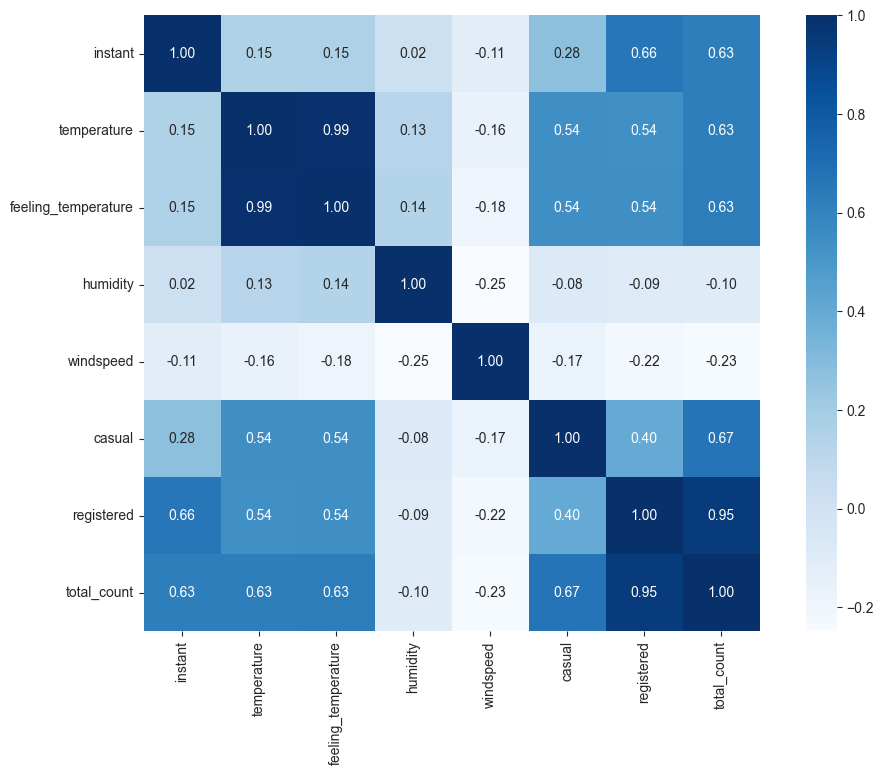

#### **Figure 1:** Correlation Matrix Heatmap

In [274]:
# Correlation matrix (heatmap) 
def plot_correlation_matrix(df, numerical_features):    
    """
    Plot a correlation matrix heatmap for numerical features in the DataFrame.
    
    Parameters:
    - df: DataFrame containing the data
    - numerical_features: List of numerical feature names
    """
    plt.figure(figsize=(12, 8))
    corr_matrix = df[numerical_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', square=True)
    
    plt.show()
    display(Markdown("#### **Figure 1:** Correlation Matrix Heatmap"))

# Plot the correlation matrix
plot_correlation_matrix(day_bike, numerical_variables)

The pair plot was generated using Seaborn. The column ``instant``, which functions as an index and carries no analytical value, was excluded from the plot. This visualization provides an overview of the distributions and relationships between every pair of numerical features. The pair plot provides a comprehensive matrix of visualizations to explore the relationships between the numerical variables. The diagonal cells show the univariate distribution of each variable using kernel density estimation (KDE), which is essential for understanding their individual spread, skewness, and modality. The off-diagonal cells reveal the bivariate relationships. In the upper triangular cells, regression lines are superimposed on scatter plots, offering a clear visual indication of the direction and strength of linear relationships between any two features. Complementing this, the lower triangular cells contain KDE contour plots that illustrate the density of observations, helping to highlight data clusters and the shape of the joint distributions.

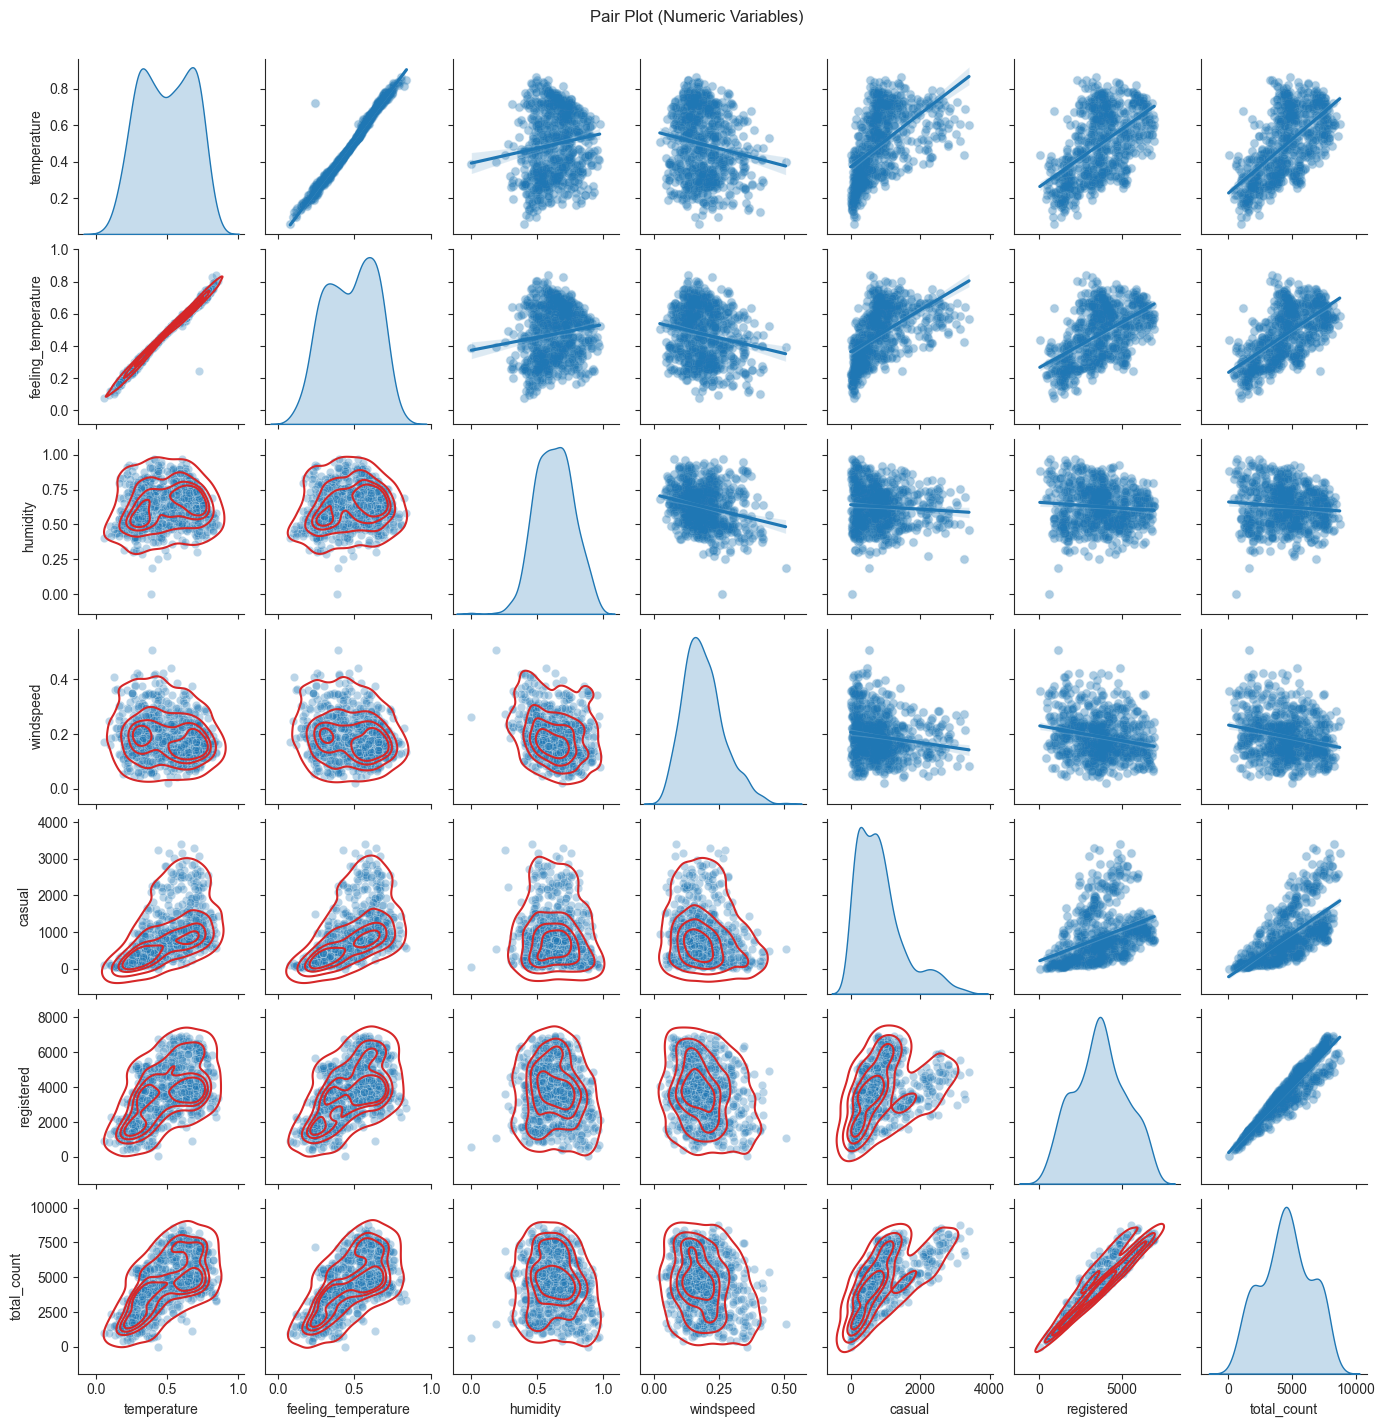

#### **Figure 2:** Pair plot of Numerical Variables

In [275]:
# Exclude 'instant' from numerical variables
num_vars = [col for col in numerical_variables if col != 'instant']
data = day_bike[num_vars]

# Optional: custom palette
sns_c = sns.color_palette()

g = sns.pairplot(
    data=data,
    diag_kind='kde',
    height=2,
    corner=False,
    plot_kws={'alpha': 0.3}
)

#  Lower triangular cells: KDE contours
g.map_lower(
    sns.kdeplot,
    levels=5,
    color=sns_c[3]
)

# Upper triangular cells: Regression lines
g.map_upper(
    sns.regplot,
    color=sns_c[0],
    scatter_kws={'alpha': 0.1}
)

# Adjust title
g.fig.suptitle('Pair Plot (Numeric Variables)', y=1.02)

plt.show()
display(Markdown("#### **Figure 2:** Pair plot of Numerical Variables"))

The analysis of the correlation heatmap and the pair plot indicates that the variables ``casual`` and ``registered`` have extremely high correlations with ``total_count`` (0.67 and 0.95). This is expected, as ``total_count`` is the direct sum of these two columns. Including casual and registered as predictors in a model to predict ``total_count`` would represent data leakage and lead to an unrealistically optimistic model performance. Therefore, these variables must be excluded from the feature set for the final predictive model. Additionally, there is a nearly perfect positive correlation of 0.99 between ``temperature`` and ``feeling_temperature``. As these two variables contain redundant information, including both in a model would lead to significant multicollinearity issues. Consequently, the ``feeling_temperature`` variable will be excluded from further analysis.

The target variable, total_count, shows a strong positive correlation with temperature (0.63). This confirms the intuitive assumption that warmer weather is associated with more bike rentals. Conversely, there are weak to moderate negative correlations with ``humidity`` (-0.10) and ``windspeed`` (-0.23).



In [276]:
# Remove specified columns from the numerical_variables list
cols_to_remove = ['casual', 'registered', 'feeling_temperature', 'instant']
numerical_variables = [col for col in numerical_variables if col not in cols_to_remove]

day_bike = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'casual'])


To confirm that multicollinearity had been resolved after removing the highly correlated variables, we calculated the Variance Inflation Factor (VIF) for each remaining numerical predictor. The VIF measures how much the variance of a regression coefficient is inflated by the presence of correlated features; values above 5 are commonly taken as evidence of problematic multicollinearity. As reported in Table 8, the VIF values for **temperature**, **humidity**, and **windspeed** are all close to 1, indicating that the predictors are effectively independent and that multicollinearity is no longer an issue.


In [277]:
# DataFrame for VIF calculation (without NaNs)
X = day_bike[numerical_variables].dropna()

# Add constant column (for VIF calculation)
X['constant'] = 1

# Calculate VIF values
vif_data = pd.DataFrame({
    'feature': numerical_variables,
    'VIF': [
        variance_inflation_factor(X.values, i)
        for i in range(len(numerical_variables))
    ]
})
display(Markdown("#### **Table 8:** Variance Inflation Factor (VIF)"))

print(vif_data)


#### **Table 8:** Variance Inflation Factor (VIF)

       feature       VIF
0  temperature  1.761323
1     humidity  1.171217
2    windspeed  1.153174
3  total_count  1.854926


##### **Individual Feature Diagnostics**

Following the initial correlation analysis, this section transitions to a more detailed diagnostic check for each individual predictor. A simple linear regression model is fitted for each of the final numerical features (temperature, humidity, and windspeed) against the total_count target.
By analyzing the model summary and a standard set of diagnostic plots for each regression, we will systematically look for several common problems:

- Significance and Influence
- Non-linearity of the response-predictor relationships
- Heteroscedasticity
- Outliers and High-Leverage Points



### **Regression result: total_count ~ temperature**

#### **Table 9:** Results OLS-Model for temperature

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     473.5
Date:                Fri, 18 Jul 2025   Prob (F-statistic):           2.81e-81
Time:                        10:58:46   Log-Likelihood:                -6386.8
No. Observations:                 731   AIC:                         1.278e+04
Df Residuals:                     729   BIC:                         1.279e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1214.6421    161.164      7.537      

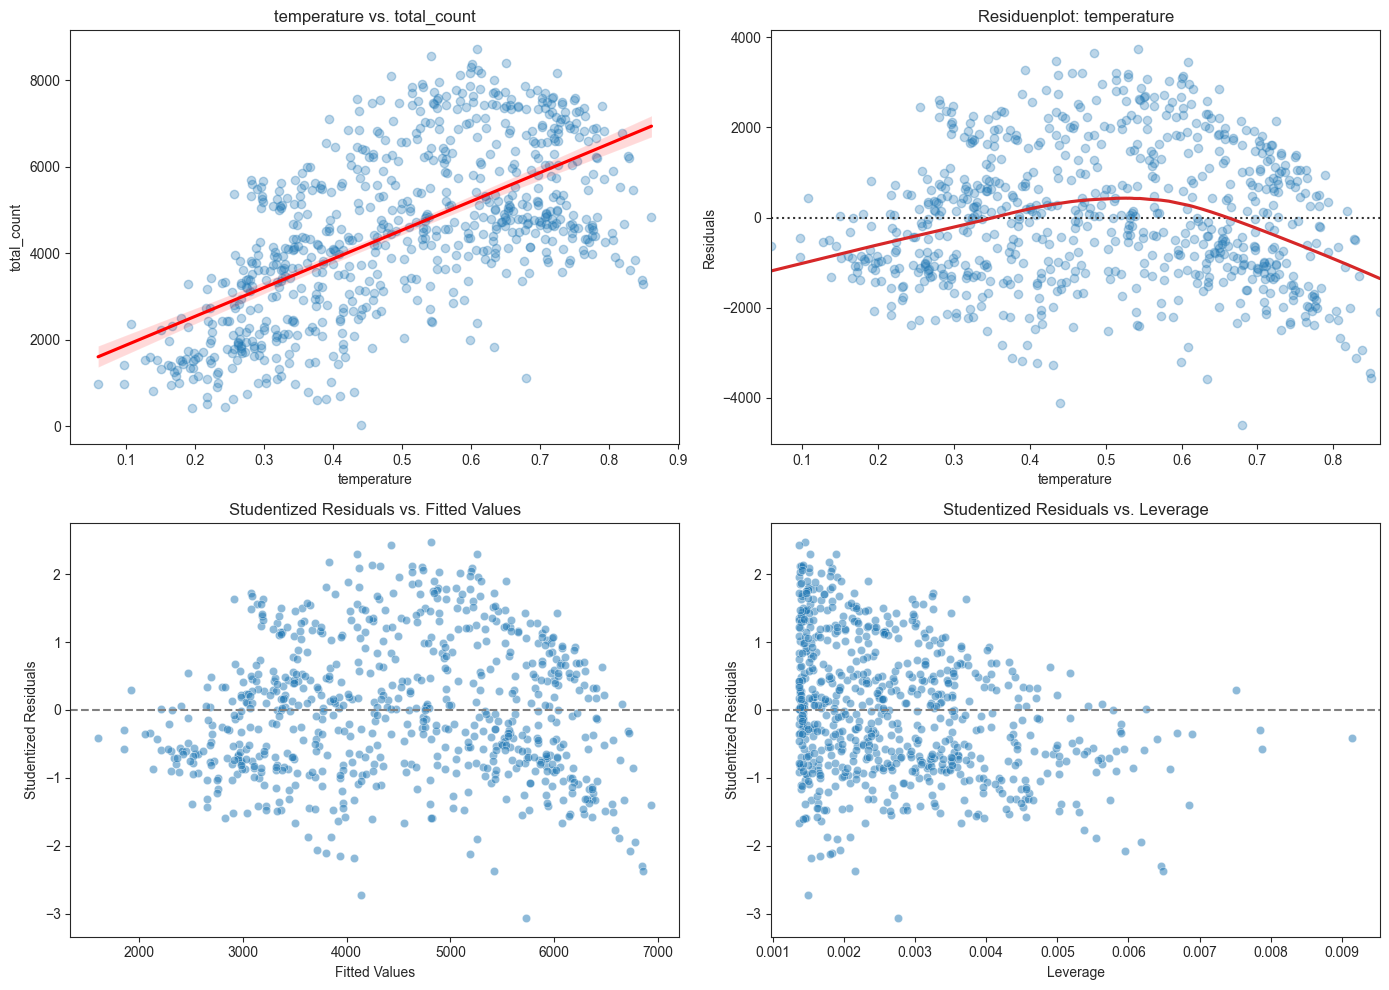

#### **Figure 3:** Regression diagnostics for temperature

---

### **Regression result: total_count ~ humidity**

#### **Table 10:** Results OLS-Model for humidity

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     7.462
Date:                Fri, 18 Jul 2025   Prob (F-statistic):            0.00645
Time:                        10:58:47   Log-Likelihood:                -6566.0
No. Observations:                 731   AIC:                         1.314e+04
Df Residuals:                     729   BIC:                         1.315e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5363.9865    322.679     16.623      0.0

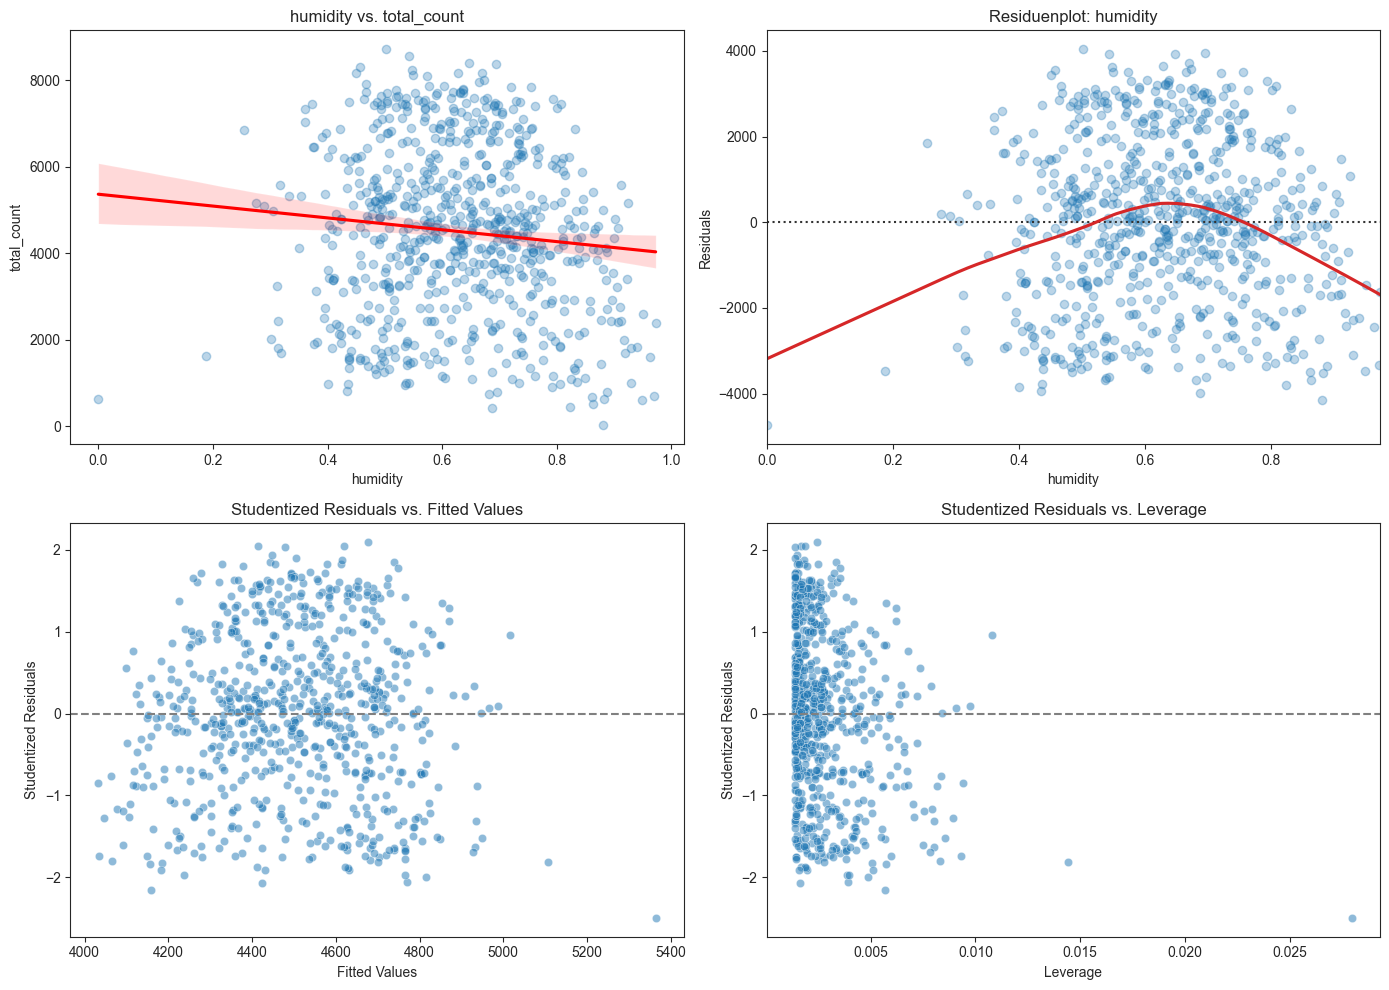

#### **Figure 4:** Regression diagnostics for humidity

---

### **Regression result: total_count ~ windspeed**

#### **Table 11:** Results OLS-Model for windspeed

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     42.44
Date:                Fri, 18 Jul 2025   Prob (F-statistic):           1.36e-10
Time:                        10:58:47   Log-Likelihood:                -6549.0
No. Observations:                 731   AIC:                         1.310e+04
Df Residuals:                     729   BIC:                         1.311e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5621.1529    185.062     30.374      0.0

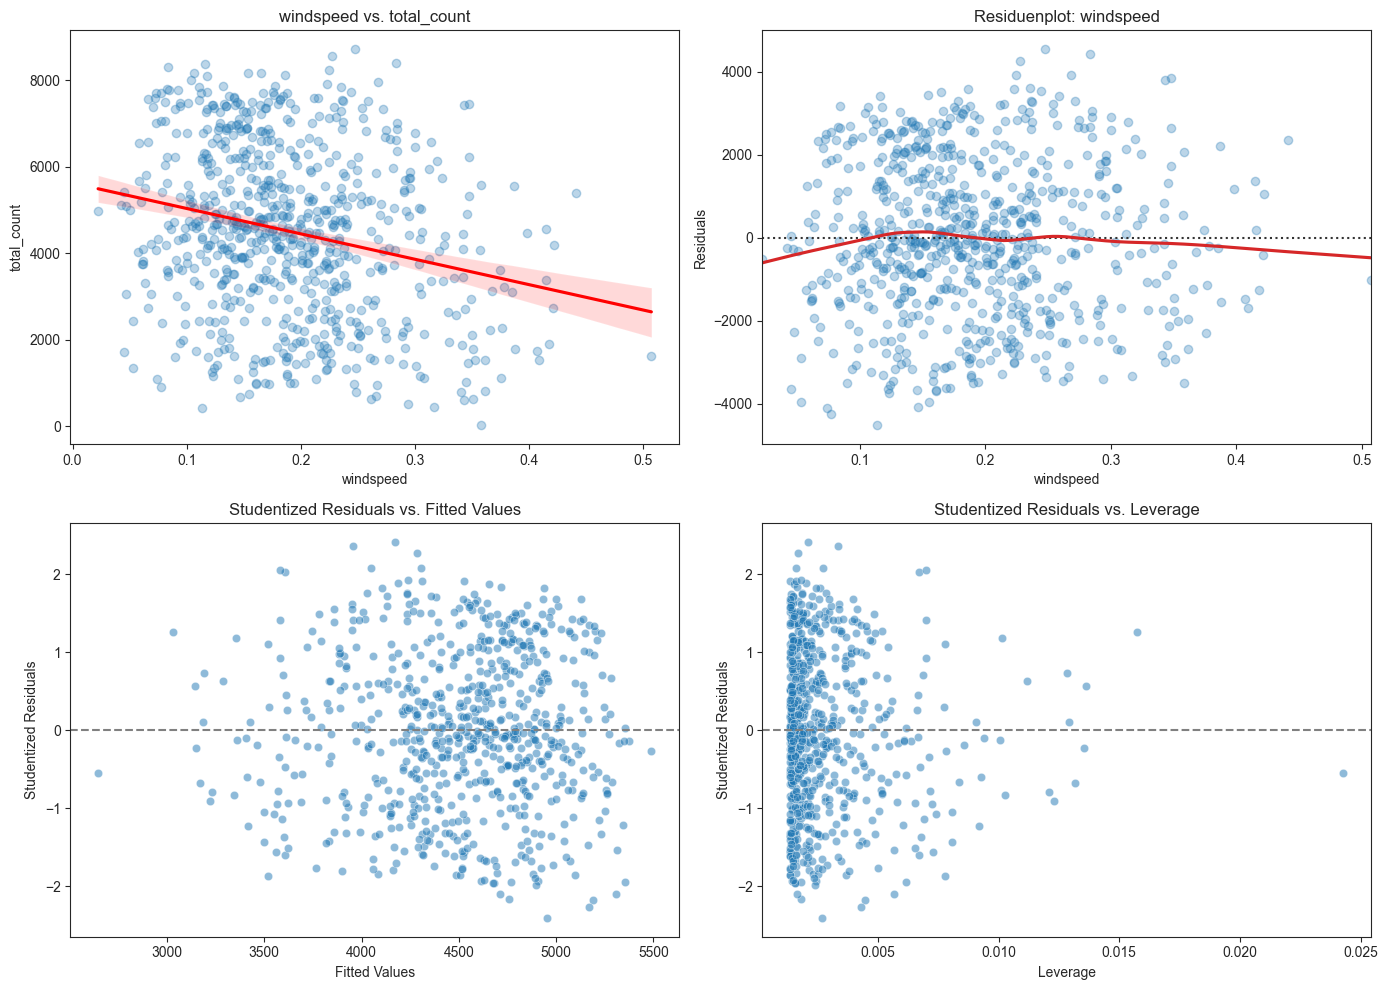

#### **Figure 5:** Regression diagnostics for windspeed

---

In [278]:
features = ['temperature', 'humidity', 'windspeed']
target = 'total_count'
t=9
f=3
# Dict to hold fitted models
models = {}
for feat in features:
    # 1. Regression with statsmodels
    X = sm.add_constant(day_bike[feat])

    model = sm.OLS(day_bike[target], X).fit()
    
    # Store model for later access
    models[feat] = model
    
    # Calculate diagnostic values
    influence = model.get_influence()
    stud_residuals = influence.resid_studentized_internal
    leverage = influence.hat_matrix_diag
    
    # 2. Model summary output
    display(Markdown(f"### **Regression result: {target} ~ {feat}**"))
    display(Markdown(f"#### **Table {t}:** Results OLS-Model for {feat}"))
    print(model.summary())
    
    # 3. Create a 2x2 grid for the plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Top row: Existing plots ---
    sns.regplot(x=feat, y=target, data=day_bike,
                ax=axes[0, 0], scatter_kws={'alpha': 0.3},
                line_kws={'color': 'red'})
    axes[0, 0].set_title(f'{feat} vs. {target}')
    
    sns.residplot(x=day_bike[feat], y=model.resid,
                  ax=axes[0, 1], lowess=True,
                  scatter_kws={'alpha': 0.3},
                  line_kws={'color': 'C3'})
    axes[0, 1].set_title(f'Residuenplot: {feat}')
    axes[0, 1].set_ylabel("Residuals")

    # --- Bottom row: New diagnostic plots ---
    # Studentized Residuals vs. Fitted Values
    sns.scatterplot(x=model.fittedvalues, y=stud_residuals, ax=axes[1, 0], alpha=0.5)
    axes[1, 0].axhline(0, ls='--', color='gray')
    axes[1, 0].set_title('Studentized Residuals vs. Fitted Values')
    axes[1, 0].set_xlabel('Fitted Values')
    axes[1, 0].set_ylabel('Studentized Residuals')

    # Studentized Residuals vs. Leverage
    sns.scatterplot(x=leverage, y=stud_residuals, ax=axes[1, 1], alpha=0.5)
    axes[1, 1].axhline(0, ls='--', color='gray')
    axes[1, 1].set_title('Studentized Residuals vs. Leverage')
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Studentized Residuals')
    
    plt.tight_layout() 
    plt.show()
    display(Markdown(f"#### **Figure {f}:** Regression diagnostics for {feat}"))
    display(Markdown("---"))
    t += 1
    f += 1

**``Temperature``:**

The regression results for temperature (see Table 9) indicate that it is a highly significant predictor of total_count, evidenced by its very low p-value. The R-squared value of 0.394 suggests that temperature alone explains approximately 39.4% of the variance in daily bike rentals.

The residual plot (Figure 3: top right) displays a distinct inverted U-shape, which is a strong indication that the relationship between temperature and bike rentals is not linear.  This suggests that a simple straight line is insufficient to capture the full relationship, as rental counts appear to level off at higher temperatures. The "Studentized Residuals vs. Fitted Values" plot (Figure 4: bottom left) indicate a roughly constant variance, implying no major issues with heteroscedasticity.  Furthermore, this plot confirms the absence of significant outliers, as no points have a studentized residual greater than ±3. The "Studentized Residuals vs. Leverage" plot (bottom right) shows that no data points exhibit extremely high leverage, meaning no single observation is unduly influencing the model.

**``Humidity``:**

The regression results for humidity are displayed in Table 10. The variable is statistically significant, but its individual explanatory power is very low, with an R-squared value of just 0.01. This indicates that humidity alone explains only about 1% of the variance in daily bike rentals. The model revealed a weak negative relationship, indicating that increased humidity is associated with slightly fewer rentals. 

An examination of the diagnostic plots of Figure 5 reveals further issues. A clear, U-shaped pattern in the residual plot (top right) points to a non-linear relationship, suggesting that both very low and very high humidity levels correspond to lower rental counts than moderate levels. Furthermore, the plot of "Studentized Residuals vs. Fitted Values" (bottom left) confirms the presence of heteroscedasticity, as the variance of the residuals is not constant. In terms of influential data points, the analysis reveals one observation with moderately high leverage, but no points qualify as significant outliers with studentized residuals beyond ±3.


**``Windspeed``:**

An analysis of windspeed (see Table 11) shows that while it is a statistically significant predictor, its individual influence on the total rental count is limited, with an R-squared value of 0.055. This suggests the variable alone accounts for just over 5% of the variance in bike rentals.

Examining the diagnostic plots (see Figure 6) reveals a more nuanced picture. Unlike the other weather variables, the residual plot (top right) for windspeed does not show a strong, obvious pattern, indicating that the assumption of linearity is not as severely violated. Regarding the error variance, the "Studentized Residuals vs. Fitted Values" plot (bottom left) displays a relatively random scatter of points, suggesting no major issues with heteroscedasticity. Finally, in terms of influential points, the "Studentized Residuals vs. Leverage" plot (bottom right) highlights a few observations with higher leverage due to their greater windspeed values, but none appear to be significant outliers that would unduly distort the model.


**Addressing Non-Linearity with Quadratic Terms**

The previous diagnostic checks revealed clear non-linear relationships for both ``temperature`` and ``humidity``. The distinct U-shaped patterns in their respective residual plots are strong evidence that a simple straight line is insufficient to capture the underlying data structure.

A common and effective strategy to address this type of non-linearity is to introduce a polynomial term into the regression model. By adding a quadratic term (the variable squared), we allow the linear model to fit a curve (a parabola) instead of a straight line. This approach can significantly improve the model's fit by capturing the observed curvature. We will now apply this technique to both ``temperature`` and ``humidity`` to assess the improvement.

## Quadratic Model: total_count ~ temperature + temperature²

#### **Table 12:** Results OLS-Model for temperature

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     301.7
Date:                Fri, 18 Jul 2025   Prob (F-statistic):           3.76e-96
Time:                        10:58:48   Log-Likelihood:                -6349.1
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     728   BIC:                         1.272e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1901.9557    382.391     -4.974   

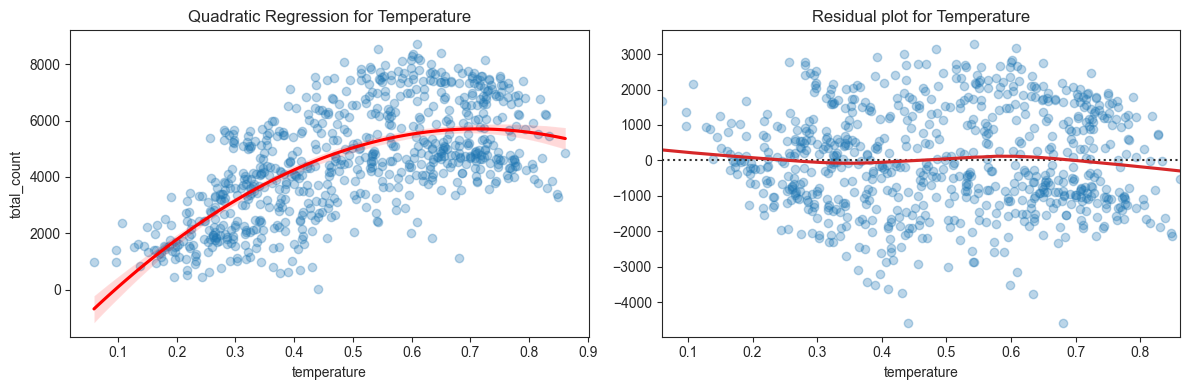

#### **Figure 5:** Regression diagnostics for temperature

---

## Quadratic Model: total_count ~ humidity + humidity²

#### **Table 13:** Results OLS-Model for humidity

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     30.86
Date:                Fri, 18 Jul 2025   Prob (F-statistic):           1.37e-13
Time:                        10:58:48   Log-Likelihood:                -6539.9
No. Observations:                 731   AIC:                         1.309e+04
Df Residuals:                     728   BIC:                         1.310e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1245.5145    954.185     -1.305      0.1

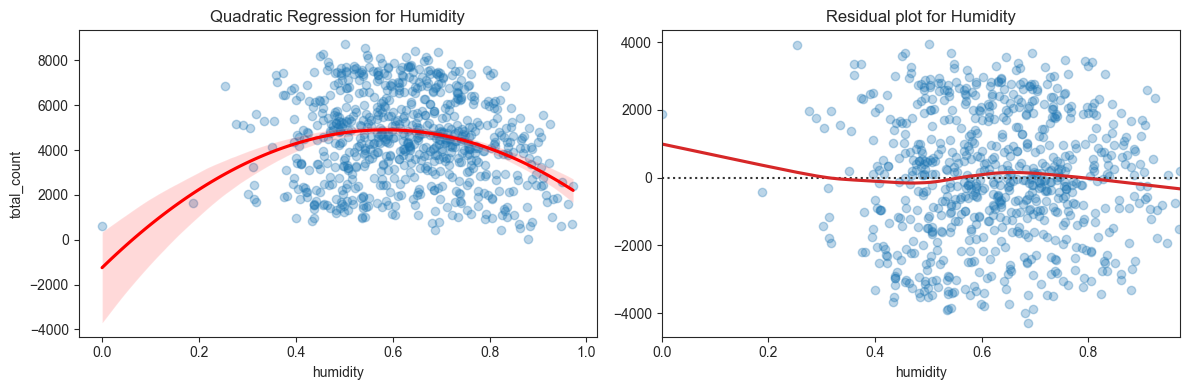

#### **Figure 6:** Regression diagnostics for humidity

---

In [279]:
t=12
f=5
for feature in ['temperature','humidity']:
    # Introduce quadratic term
    quad_feature_name = f'{feature}2'
    day_bike[quad_feature_name] = day_bike[feature]**2

    # Define features and fit the model
    X = sm.add_constant(day_bike[[feature, quad_feature_name]])
    model_poly = sm.OLS(day_bike['total_count'], X).fit()

    # Display model summary
    display(Markdown(f"## Quadratic Model: total_count ~ {feature} + {feature}²"))
    display(Markdown(f"#### **Table {t}:** Results OLS-Model for {feature}"))
    print(model_poly.summary())

    # Plot the results
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot 1: Quadratic regression plot
    sns.regplot(x=feature, y='total_count', data=day_bike, order=2,
                ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[0].set_title(f'Quadratic Regression for {feature.capitalize()}')
    
    # Plot 2: Residual plot
    sns.residplot(x=day_bike[feature], y=model_poly.resid,
                  ax=axes[1], lowess=True, scatter_kws={'alpha':0.3},
                  line_kws={'color':'C3'})
    axes[1].set_title(f'Residual plot for {feature.capitalize()}')
    
    plt.tight_layout()
    plt.show()
    display(Markdown(f"#### **Figure {f}:** Regression diagnostics for {feature}"))
    display(Markdown("---")) # Add a separator
    t= t + 1
    f = f + 1

# Drop Humidity2 and temperature2 from the DataFrame
day_bike.drop(columns=['humidity2', 'temperature2'], inplace=True)

**``Temperature``:**

The analysis of the quadratic model for temperature shows a significant improvement over the simple linear model (see Table 12). The model summary reveals that the new  $temperature^2$ term is highly statistically significant (p < 0.001). Furthermore, the Adjusted R-squared value has increased substantially from 0.394 to 0.453, indicating that the quadratic model provides a better fit to the data.

This improvement is visually confirmed by the diagnostic plots in Figure 5. The quadratic regression curve (left) now more accurately captures the relationship where rental counts level off at higher temperatures. Most importantly, the residual plot (right) no longer exhibits the strong inverted U-shape seen previously. The residuals are now more randomly scattered around the zero line, confirming that adding the quadratic term has successfully addressed the non-linearity problem for this variable.

The quadratic model fits the data better because it captures a more realistic, non-linear story about human behavior. While a simple linear model assumes that every degree of temperature increase has the same effect, the quadratic model reflects the concept of diminishing returns.

Specifically, it shows that at low temperatures, a warming trend has a strong positive impact on bike rentals. However, as the temperature becomes comfortably warm, the positive effect of each additional degree lessens, causing the rental count to level off. The model can also capture a potential decrease in ridership at extremely high temperatures, an effect a simple linear model cannot represent.


**``Humidity``:**

Similar to temperature, the quadratic model for humidity shows a marked improvement. The new $humidity^2$ term is statistically significant, and the Adjusted R-squared has increased from 0.009 to 0.076 (see Table 13). While the overall explanatory power remains low, this is a substantial relative improvement.

The diagnostic plots, displayed in Figure 6, confirm the better fit. The quadratic regression curve (left) now effectively models the U-shaped relationship where rental counts are lower at both very low and very high humidity levels. The new residual plot (right) shows that the previous strong pattern has been largely mitigated, resulting in a more random scatter of points around the zero line. This confirms that adding a quadratic term was a successful strategy for this variable as well.

The model suggests that bike rentals peak at moderate humidity levels, while both very low and very high humidity suppress ridership. Very low humidity can be uncomfortable, while very high humidity feels "muggy" and oppressive, making physical activities like cycling less pleasant. The quadratic model successfully captures this preference for a comfortable, moderate humidity range, which a simple linear model could not.

To further quantify and visualize the presence of unusual data points in the numerical features, boxplots were generated for each variable. Boxplots are a useful tool for displaying the distribution of the data, showing the median, interquartile range (IQR), and identifying potential high leverage points.

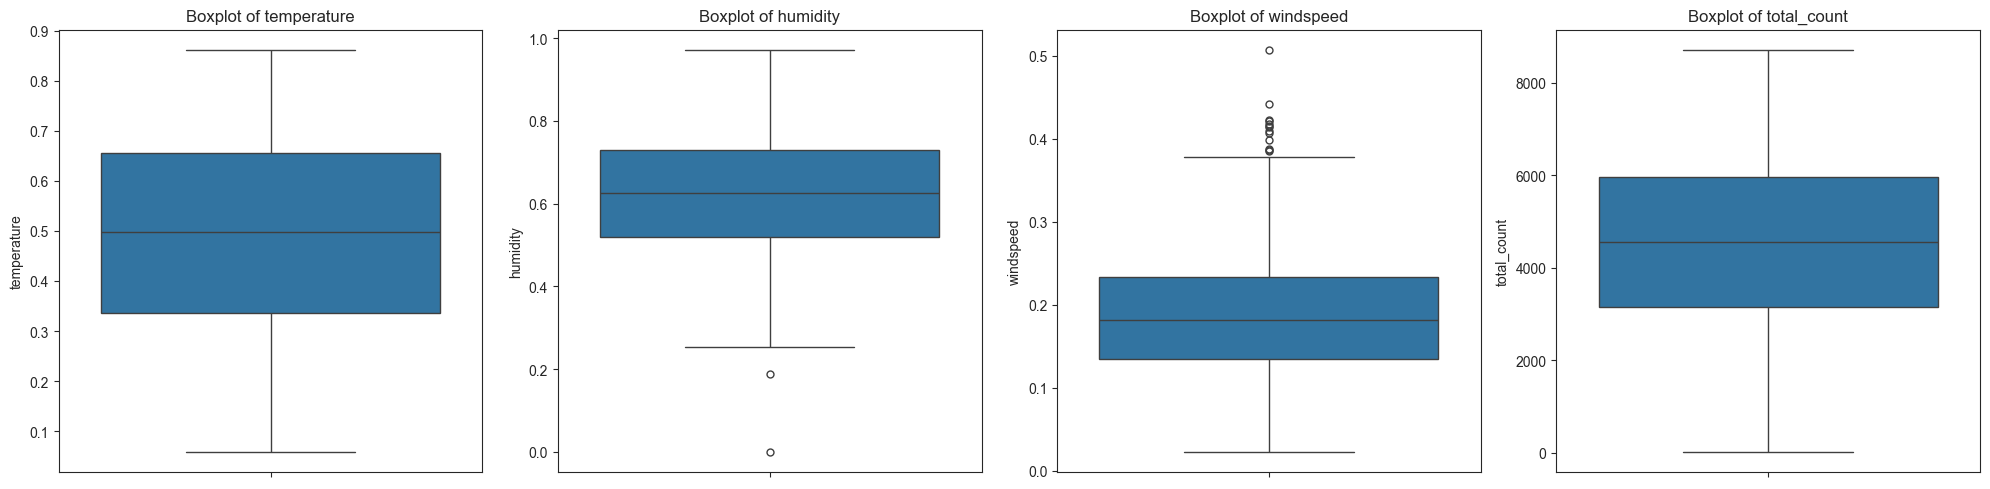

#### **Figure 7 :** Boxplot of Numerical Variables

In [280]:
# Boxplots for Numerical Features to identify high leverage points

# List of numerical features to inspect
num_features = ['temperature', 'humidity', 'windspeed', 'total_count']



# Create one row of subplots, one boxplot per feature
fig, axes = plt.subplots(nrows=1,
                         ncols=len(num_features),
                         figsize=(20, 5),
                         sharey=False)

# Loop over features and axes to draw boxplots
for ax, feature in zip(axes, num_features):
    sns.boxplot(y=day_bike[feature],
                ax=ax,
                color='C0',
                fliersize=5,
                linewidth=1)
    ax.set_title(f'Boxplot of {feature}')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()
display(Markdown(f"#### **Figure 7 :** Boxplot of Numerical Variables"))

An examination of the boxplots in Figure 7 provides several insights into the data distributions. Both ``temperature`` and the target variable ``total_count`` show relatively symmetrical distributions with no apparent outliers. In contrast, the ``humidity`` variable is slightly skewed and includes a few outliers at its lower end, which correspond to days with unusually low humidity. A more pronounced pattern is visible in the ``windspeed`` data, which is noticeably right-skewed and exhibits several outliers on the higher end, representing days with exceptionally high windspeeds.

#### 2.2.2 Categorical Features

To understand how different categorical variables impact bike rentals, a series of boxplots were generated. Each plot visualizes the distribution of ``total_count`` across the different categories of a given feature. This method is effective for comparing the median rental counts and identifying variations in rental patterns based on factors like season, year, or weather conditions.



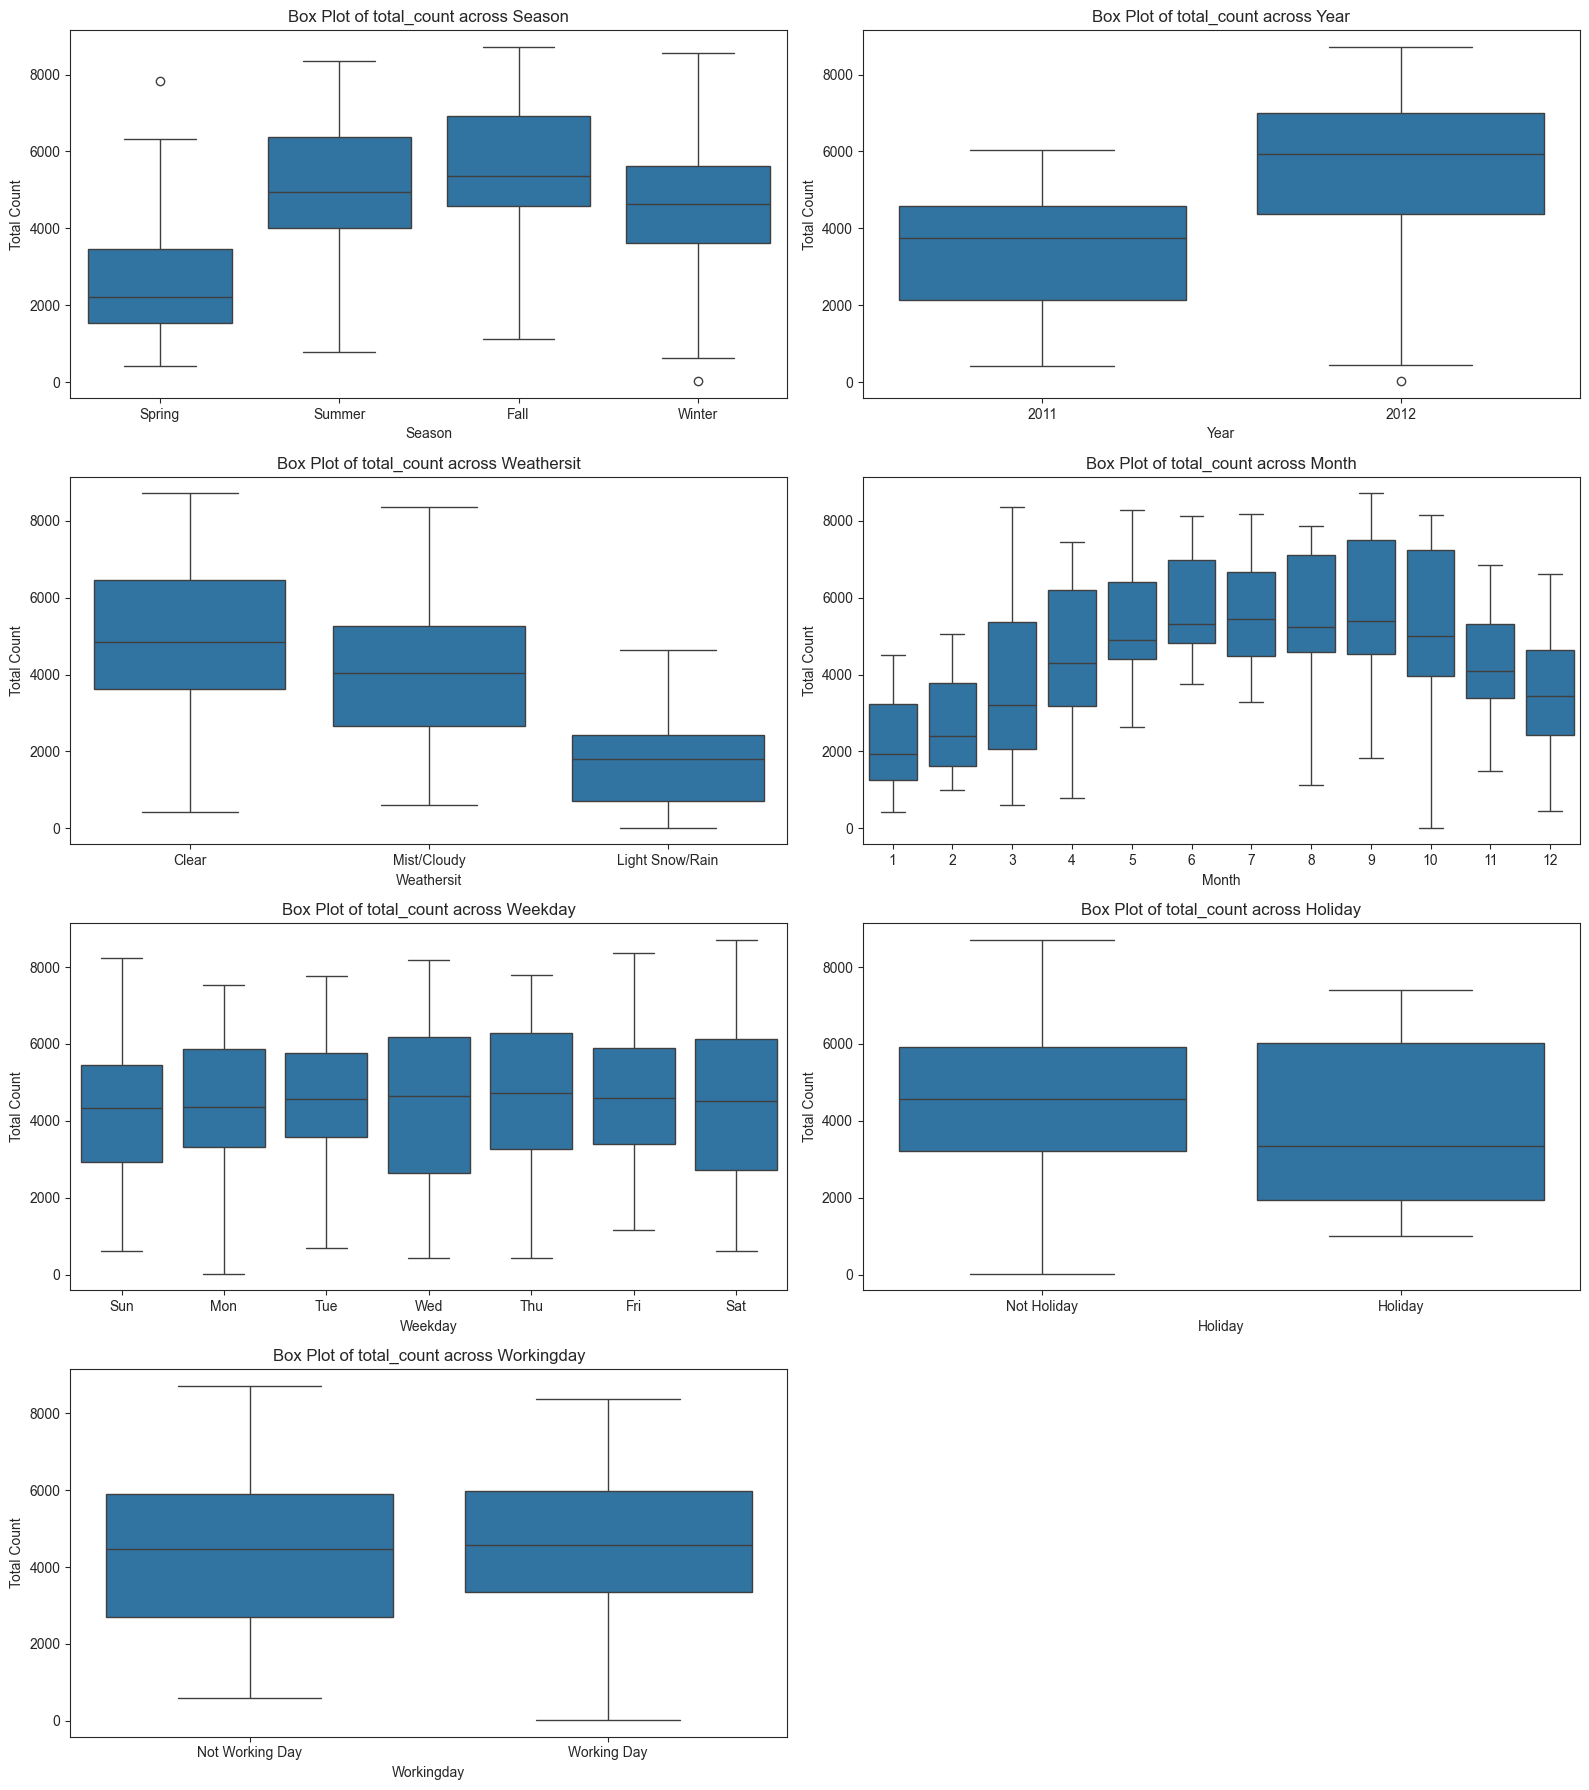

#### **Figure 8:** Boxplots of Categorical Variables vs. Total Count

In [281]:
#Boxplots for Categorical Features vs. Total Count


# Define the categorical features to be plotted against the target variable
cat_features_for_plot = ['season', 'year', 'weathersit', 'month', 'weekday', 'holiday', 'workingday']
target = 'total_count'

# Create a figure and a set of subplots. A 4x2 grid.
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 18))
# Flatten the axes array for easy iteration, which simplifies assigning plots to subplots
axes = axes.flatten()


# --- Plotting Loop ---
# Iterate through the list of categorical features and create a boxplot for each.
# 'enumerate' provides an index 'i' and the 'feature' name.
for i, feature in enumerate(cat_features_for_plot):
    ax = axes[i]
    # Create the boxplot using seaborn, assigning it to the current subplot axis
    sns.boxplot(data=day_bike, x=feature, y=target, ax=ax)
    # Set a descriptive title for each subplot
    ax.set_title(f'Box Plot of {target} across {feature.capitalize()}')
    ax.set_ylabel('Total Count')
    ax.set_xlabel(feature.capitalize())

# --- Customizing Labels for better readability ---
# Set both tick positions and labels to avoid the UserWarning
axes[0].set_xticks(ticks=[0, 1, 2, 3], labels=['Spring', 'Summer', 'Fall', 'Winter']) # For 'season'
axes[1].set_xticks(ticks=[0, 1], labels=['2011', '2012']) # For 'year'
axes[2].set_xticks(ticks=[0, 1, 2], labels=['Clear', 'Mist/Cloudy', 'Light Snow/Rain']) # For 'weathersit'
axes[4].set_xticks(ticks=range(7), labels=['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']) # For 'weekday'
axes[5].set_xticks(ticks=[0, 1], labels=['Not Holiday', 'Holiday']) # For 'holiday'
axes[6].set_xticks(ticks=[0, 1], labels=['Not Working Day', 'Working Day']) # For 'workingday'

# Hide the last subplot if it's unused (since we have 7 plots in a 4x2 grid)
axes[7].set_visible(False)

# Adjust the layout automatically to prevent titles and labels from overlapping
plt.tight_layout()
# Display the generated
plt.show()
display(Markdown("#### **Figure 8:** Boxplots of Categorical Variables vs. Total Count"))

An analysis of the categorical features reveals distinct patterns in bike rental usage. A clear seasonal trend is evident, with ridership peaking in the Fall and Summer while being lowest in the Spring. This trend is further illuminated by the monthly data, which shows the highest rental counts occurring between May and October. A significant growth in the system's popularity is also visible, with the median number of rentals in 2012 being substantially higher than in 2011.

Rider behavior also varies with the type of day. As expected, the weather situation is a strong determinant; clear days show the highest usage, while days with light snow or rain have the lowest. Interestingly, while weekdays have a stable rental pattern, weekends show a much wider distribution, indicating more variability. The distinction between working and non-working days further clarifies this, showing higher median rentals on working days, while holidays have a noticeably lower ridership compared to non-holidays.

Collectively, these distinct variations in rental distributions confirm that all the analyzed categorical features have a significant influence on the total_count and are therefore important for the predictive model.

### 2.2.3 Outlier and High-Leverage Point Analysis

Based on the initial diagnostic analysis of individual features, which hinted at the existence of some high-leverage points, a more in-depth analysis is now performed. The previous visual inspection was limited to single-variable models. Therefore, to gain a more comprehensive understanding and to quantitatively identify influential points, this analysis uses a multivariate regression model that considers all relevant predictors simultaneously. The procedure involves several key steps as reflected in the code.

First, a complete feature set is prepared by combining the final numerical predictors (temperature, humidity, windspeed) with the categorical features. To make the categorical data suitable for a regression model, they are transformed into a numerical format using one-hot encoding (``pd.get_dummies``) with the ``drop_first=True`` parameter used to avoid perfect multicollinearity among the new dummy variables. These are then combined with the original numerical features to create a complete feature set.

Next, a custom function (``detect_outliers_and_leverage``) fits an Ordinary Least Squares (OLS) regression model to the full dataset. After fitting, this function calculates two key influence measures for each data point The studentized residuals, which identify potential outliers by measuring how large the prediction error is, and the leverage. A point with high leverage is distant from other points in the feature space and can disproportionately pull the regression line towards it, with the threshold here calculated as:

``leverage_thresh`` = $(\frac{p+1}{n})$ * ``leverage_factor``, 

where $p$ is number of number of predictors and $n$ number of observations. The ``leverage_factor`` is a multiplier to control the sensitivity of the detection of high leverage points. The function then flags a point as a potential outlier if its studentized residual is greater than ±3, and as a high-leverage point if its leverage value exceeds the calculated threshold.

In [282]:

def detect_outliers_and_leverage(df, feature_cols, target_col, outlier_factor=3.0, leverage_factor=1.0):
    """
    Fit an OLS regression model on the specified features and target,
    compute influence measures and flags:
      - is_potential_outlier: |studentized residual| > outlier_factor
      - is_high_leverage: hat value > (p+1)/n
    """
    # Prepare design matrix
    X = df[feature_cols].copy()
    X = sm.add_constant(X)
    y = df[target_col]

    # Fit OLS model
    model = sm.OLS(y, X).fit()

    # Influence measures
    infl = model.get_influence()
    hat_vals = infl.hat_matrix_diag
    stud_resid = infl.resid_studentized_internal

    # Thresholds
    n, p = X.shape[0], X.shape[1] - 1
    #print(n, p )
    leverage_thresh = ((p + 1) / n) * leverage_factor
    #print(leverage_thresh)

    # Flags
    is_outlier = np.abs(stud_resid) > outlier_factor
    is_high_lev = hat_vals > leverage_thresh

    # Build results
    results = pd.DataFrame({
        'residuals': model.resid,
        'standardized_residuals': stud_resid,
        'leverage': hat_vals,
        'is_potential_outlier': is_outlier,
        'is_high_leverage': is_high_lev
    }, index=df.index)

    return results, model


In [283]:
# Applying the Outlier/Leverage Detection Function


# 1. Define the feature sets and the target variable
numerical_features = ['temperature', 'humidity', 'windspeed']
# Note: 'month' and 'weekday' can be treated as categorical
categorical_features = ['season', 'year', 'month', 'weekday', 'weathersit', 'holiday', 'workingday']
target_col = 'total_count'

# 2. Create one-hot encoded features from the categorical variables
# Using drop_first=True to avoid perfect multicollinearity
day_bike_dummies = pd.get_dummies(day_bike[categorical_features], 
                                  columns=categorical_features, 
                                  drop_first=True, 
                                  dtype=float)

# 3. Combine the numerical features and the new dummy variables
X_full = pd.concat([day_bike[numerical_features], day_bike_dummies], axis=1)

df_for_model = pd.concat([X_full, day_bike[target_col]], axis=1)

# 4. Get the final list of all predictor columns
all_feature_cols = X_full.columns.tolist()

# 5. Call the detection function with the prepared data
# We can adjust the outlier_fraction, e.g., to 5% for the full model
influence_df, full_model = detect_outliers_and_leverage(
    df=df_for_model,
    feature_cols=all_feature_cols,
    target_col=target_col,
    leverage_factor=2.0,  # Adjust leverage factor 
)

# 6. Display the summary of the fitted regression model
display(Markdown("#### **Table 14:** Full Regression Model Summary"))

print(full_model.summary())

# 7. Display the points that were flagged as either potential outliers or high-leverage
display(Markdown("#### **Table 15:** Identified Potential Outliers and/or High-Leverage Points"))
problematic_points = influence_df[
    (influence_df['is_potential_outlier']) | (influence_df['is_high_leverage'])
]
display(problematic_points)

print(f"\nTotal number of problematic points found: {len(problematic_points)}")

#### **Table 14:** Full Regression Model Summary

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     145.3
Date:                Fri, 18 Jul 2025   Prob (F-statistic):          1.49e-266
Time:                        10:58:50   Log-Likelihood:                -5881.0
No. Observations:                 731   AIC:                         1.182e+04
Df Residuals:                     703   BIC:                         1.195e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1543.5518    235.129      6.565   

#### **Table 15:** Identified Potential Outliers and/or High-Leverage Points

,residuals,standardized_residuals,leverage,is_potential_outlier,is_high_leverage
68,-849.397951,-1.210338,0.168286,False,True
89,1129.975980,1.547447,0.099525,False,True
104,88.644706,0.120317,0.083322,False,True
184,2458.796250,3.322201,0.074965,True,False
238,-2301.267669,-3.058909,0.044202,True,False
265,-2702.681903,-3.631066,0.064408,True,False
301,-246.595684,-0.334712,0.083373,False,True
314,675.277341,0.915233,0.080683,False,True
339,1274.780209,1.729367,0.082384,False,True
359,273.015661,0.370957,0.085271,False,True



Total number of problematic points found: 23


The summary of the full multivariate model, detailed in Table 14, shows an Adjusted R-squared of 0.848. This is a strong and realistic measure of model fit, indicating that the selected features explain about 84.8% of the variance in daily bike rentals.

The outlier/high-leverage analysis identified 23 problematic points that are either outliers or have high leverage and displayed in Table 15. A closer inspection of these 23 problematic points reveals different types of influence. Some points are flagged only for high leverage, indicating days with unusual conditions that the model still predicted accurately. Other points are flagged only as outliers, representing days where the rental count was unexpectedly high or low given the conditions, possibly due to unrecorded events. Instead of removing these points and risking information loss, a more detailed diagnostic analysis was performed to understand the root cause of their influence and to identify potential data errors.

To achieve this, a custom function was developed (``analyze_influential_points_extended``) to generate a detailed profile for each high-leverage point. This function analyzes each point to determine which specific features were most unusual. For numerical features, it identifies the "culprit" by finding the variable with the highest absolute Z-score, which measures how many standard deviations a value is from its mean. For categorical features, it identifies the "culprit" by finding the category with the lowest frequency, pinpointing the rarest event for that day.

In [284]:
def analyze_influential_points_extended(df_original, influence_df, point_type='is_high_leverage', z_score_threshold=2.0):
    """
    Analyzes influential data points to identify which numerical and categorical 
    features are most likely responsible for their influence.

    For each influential point, the function determines:
    1. The numerical feature with the highest absolute Z-score, indicating an extreme value.
    2. The categorical feature with the rarest category (lowest frequency), indicating an unusual category.

    Args:
        df_original (pd.DataFrame): The original DataFrame containing all features.
        influence_df (pd.DataFrame): DataFrame from a regression model's influence results,
                                     containing leverage and residual statistics.
        point_type (str): The column name in `influence_df` that flags the points to analyze
                          (e.g., 'is_high_leverage' or 'is_potential_outlier').
        z_score_threshold (float): A threshold for filtering results, though currently unused in the
                                   reporting logic, it's kept for potential future use.

    Returns:
        pd.DataFrame: A summary DataFrame detailing the most likely numerical and categorical
                      culprits for each influential point, sorted by leverage.
    """
    # 1. Get indices of points to analyze
    # Filter the influence DataFrame to get only the rows flagged by `point_type` (e.g., where 'is_high_leverage' is True).
    # Then, extract the index of these rows to identify which data points to analyze.
    point_indices = influence_df[influence_df[point_type]].index
    
    # 2. Identify numerical and categorical features to analyze
    numerical_features = ['temperature', 'humidity', 'windspeed']
    categorical_features = ['season', 'year', 'month', 'weekday', 'weathersit', 'holiday', 'workingday']

    # 3. Pre-calculate stats for numerical and categorical features
    # Calculate the mean and standard deviation for all numerical columns at once.
    num_stats = df_original[numerical_features].agg(['mean', 'std'])
    # Calculate the frequency of each category in each categorical feature, normalized to get proportions.
    cat_freqs = {col: df_original[col].value_counts(normalize=True) for col in categorical_features}
    # Initialize a list to store the analysis results
    analysis_results = []

    # 4. Iterate over each influential point
    for idx in point_indices:
        # Extract the data point from the original DataFrame using the index
        point_data = df_original.loc[idx]
        
        # --- Numerical Analysis (Highest Z-Score) ---
        # Initialize variables to track the maximum Z-score and the corresponding feature and value
        max_z = -1
        num_culprit_feature = None
        num_culprit_value = None
        # Iterate over each numerical feature to calculate the Z-score
        # The Z-score is calculated as the absolute value of (value - mean) / std
        for feature in numerical_features:
            val, mean, std = point_data[feature], num_stats.loc['mean', feature], num_stats.loc['std', feature]
            # Calculate Z-score only if standard deviation is greater than zero to avoid division by zero
            if std > 0:
                z_score = abs((val - mean) / std)
                # If the Z-score is greater than the current maximum, update the maximum and the corresponding feature and value
                if z_score > max_z:
                    max_z = z_score
                    num_culprit_feature = feature
                    num_culprit_value = val
        
        # --- Categorical Analysis (Rarest Category) ---
        # Initialize variables to track the minimum frequency and the corresponding feature and value
        min_freq = 1.1
        cat_culprit_feature = None
        cat_culprit_value = None
        # Iterate over each categorical feature to find the category with the lowest frequency
        # The frequency is obtained from the pre-calculated category frequencies.
        for feature in categorical_features:
            val = point_data[feature]
            freq = cat_freqs[feature].get(val, 0)
            # If the frequency is lower than the current minimum, update the minimum and the corresponding feature and value
            if freq < min_freq:
                min_freq = freq
                cat_culprit_feature = feature
                cat_culprit_value = val

        # Add results to list
        analysis_results.append({
            'index': idx,
            'Numerical Culprit': num_culprit_feature,
            'Numerical Value': num_culprit_value,
            'z_score': round(max_z, 2),
            'Categorical Culprit': cat_culprit_feature,
            'Category Value': cat_culprit_value,
            'Category Frequency': round(min_freq, 4),
            'leverage': round(influence_df.loc[idx, 'leverage'], 4),
            'std_residual': round(influence_df.loc[idx, 'standardized_residuals'], 2)
        })

    return pd.DataFrame(analysis_results).sort_values(by='leverage', ascending=False)

# --- Perform the extended analysis ---

display(Markdown("#### **Table 16:** Result of the extended analysis of the high leverage points"))
extended_analysis = analyze_influential_points_extended(day_bike, influence_df, point_type='is_high_leverage')
display(extended_analysis)


#### **Table 16:** Result of the extended analysis of the high leverage points

,index,Numerical Culprit,Numerical Value,z_score,Categorical Culprit,Category Value,Category Frequency,leverage,std_residual
0,68,humidity,0.000000,4.41,weathersit,3.0,0.0287,0.1683,-1.21
10,724,temperature,0.291304,1.11,holiday,1.0,0.0287,0.0999,-1.92
1,89,humidity,0.918333,2.04,weathersit,3.0,0.0287,0.0995,1.55
11,725,windspeed,0.316546,1.63,weathersit,3.0,0.0287,0.0940,-0.48
6,359,temperature,0.321739,0.95,holiday,1.0,0.0287,0.0853,0.37
3,301,windspeed,0.351371,2.08,weathersit,3.0,0.0287,0.0834,-0.33
2,104,windspeed,0.226375,0.46,holiday,1.0,0.0287,0.0833,0.12
8,567,humidity,0.865417,1.67,weathersit,3.0,0.0287,0.0831,1.17
5,339,humidity,0.949583,2.26,weathersit,3.0,0.0287,0.0824,1.73
4,314,windspeed,0.314675,1.60,holiday,1.0,0.0287,0.0807,0.92


The results of this in-depth analysis, shown in Table 16, allow for a targeted investigation of data inconsistencies. The most significant finding is related to point 68. This point has the highest leverage in the dataset (0.168) and the analysis identifies humidity as the numerical culprit with an extreme Z-score of 4.4. Crucially, the categorical culprit is weathersit with a value of 3, corresponding to "Light Snow/Rain." This combination is physically impossible, as a day with precipitation cannot have a humidity of 0. This indicates a clear data error for this specific observation. Other influential points are primarily driven by the rare occurrence of weathersit=3 or holidays, which are legitimate but infrequent events. Additionally other points were investigated, but they were not removed as no further obvious data errors or physical contradictions were found. Based on the identification of a clear data error, the decision was made to remove the single contradictory point (index 68) before proceeding to the final modeling phase.

In [285]:
# Define the index to remove
index_to_remove = 68

# Remove the row with the specified index
day_bike.drop(index=index_to_remove, inplace=True)

## 3. Modeling and Optimization

This chapter moves from data analysis to the core task of creating and optimizing forecasting models. As outlined in the previous sections, the goal is to predict the ``total_count`` of daily bike rentals, a continuous numerical value. This makes the task a regression problem.

To find the most effective solution, we will explore and compare four different regression models. The approach begins with a simple linear regression as a baseline and progressively introduces more advanced concepts like regularization and ensemble methods. A standardized workflow is applied to each model, leveraging ``scikit-learn``'s ``Pipeline`` functionality to chain together preprocessing steps such as feature scaling and one-hot encoding with the regression algorithm. This ensures that data transformations are handled correctly and consistently, particularly within cross-validation loops, preventing data leakage.

The models to be evaluated are:

-  **Linear Regression**: A baseline model assuming a linear relationship between features and the target. While simple and interpretable, its performance can be limited by complex, non-linear patterns in the data.

- **Ridge Regression**: An extension of linear regression that incorporates L2 regularization. By penalizing the squared magnitude of the coefficients, it prevents overfitting and improves stability, especially when dealing with many or correlated features.

- **Lasso Regression**: Similar to Ridge but uses L1 regularization. A key feature of Lasso is its ability to shrink some coefficients to exactly zero, thus performing automatic feature selection.

- **Random Forest Regression**: A powerful ensemble method that builds multiple decision trees and merges their predictions. It can natively capture complex, non-linear relationships and interactions between features, making it a strong candidate for this dataset.

To optimize performance, key hyperparameters for the Ridge, Lasso, and Random Forest models are tuned using ``GridSearchCV`` with cross-validation. This process systematically searches for the best combination of parameters, such as the regularization strength (``lambda``) for Ridge and Lasso, and tree-based parameters like ``max_depth`` for the Random Forest.  To ensure a robust and unbiased evaluation, the dataset is first split into a training set (80%) and a test set (20%). All feature selection and hyperparameter tuning steps are performed exclusively on the training data to ensure that the final model evaluation on the set is unbiased and provides a realistic estimate of real-world performance.

### 3.1 Linear Regression

We begin with Linear Regression, the foundational model for this analysis. Due to the large number of potential predictors created after one-hot encoding the categorical variables, a method is needed to select only the most impactful features. This helps to create a more interpretable and potentially more robust model by reducing complexity and noise. For this purpose, we employ forward stepwise feature selection.

Forward stepwise selection is an iterative algorithm that builds a model by progressively adding one feature at a time until no further improvement can be made. The core logic of the forward_stepwise_selection function implemented here is to find the optimal subset of features that minimizes the cross-validated error. The algorithm begins with an empty model. In each step, it temporarily adds each of the remaining available features to the current set of selected features. For each new potential model, a 7-fold cross-validation is performed to calculate the average Mean Squared Error (MSE). The single feature that provides the greatest improvement, that is, the lowest cross-validated MSE is then permanently added to the model. This process is repeated, with the model growing by one feature at each step, until adding any of the remaining features no longer lowers the cross-validation error. The final model is the one with the combination of features that achieved the lowest MSE observed throughout this entire iterative process. This ensures a data-driven approach to feature selection that is optimized for predictive performance.

Step 0: Null Model MSE = 3759829.36
Step 1: Added 'temperature', CV MSE: 2261328.46
Step 2: Added 'year_1', CV MSE: 1246936.95
Step 3: Added 'season_4', CV MSE: 1095922.83
Step 4: Added 'weathersit_3', CV MSE: 974243.66
Step 5: Added 'weathersit_2', CV MSE: 895025.21
Step 6: Added 'season_2', CV MSE: 833931.14
Step 7: Added 'month_9', CV MSE: 794596.34
Step 8: Added 'windspeed', CV MSE: 759922.48
Step 9: Added 'humidity', CV MSE: 724400.52
Step 10: Added 'season_3', CV MSE: 709883.31
Step 11: Added 'month_10', CV MSE: 697320.07
Step 12: Added 'month_3', CV MSE: 687762.75
Step 13: Added 'holiday_1', CV MSE: 680894.81
Step 14: Added 'month_7', CV MSE: 676811.52
Step 15: Added 'month_5', CV MSE: 674035.73
Step 16: Added 'weekday_6', CV MSE: 672753.19
Step 17: Added 'workingday_1', CV MSE: 660831.00
Step 18: Added 'weekday_4', CV MSE: 660837.89
Step 19: Added 'weekday_1', CV MSE: 661685.06
Step 20: Added 'month_8', CV MSE: 662654.61
Step 21: Added 'month_2', CV MSE: 664490.46
Step 22: Adde

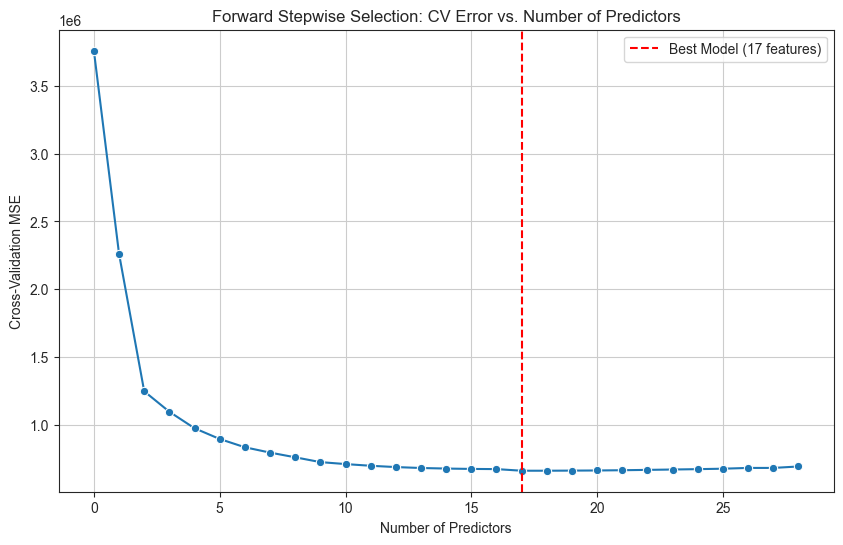

#### **Figure 9:** Forward Stepwise Selection: CV Error vs. Number of Predictors

In [286]:
# --- 1. Data Preparation (linear) ---

df_model_linear = day_bike
# Define features (X) and target (y)
X_linear = df_model_linear.drop('total_count', axis=1)
y_linear = df_model_linear['total_count']
# Split the data into training and testing sets
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)
# Identify numerical and categorical features for the preprocessor
categorical_features_linear = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_linear = [col for col in X_linear.columns if col not in categorical_features_linear]                                     

# Create a preprocessor for scaling and one-hot encoding
# Using drop='first' to avoid multicollinearity (dummy variable trap)
# Using sparse_output=False to ensure dense arrays for subsequent pipeline steps
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_linear),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_linear)
    ],
    remainder='passthrough'
)

# Get the full list of feature names after preprocessing
preprocessor_linear.fit(X_linear)
ohe_names_linear = preprocessor_linear.named_transformers_['cat'].get_feature_names_out(categorical_features_linear)
all_names_linear = numerical_features_linear + ohe_names_linear.tolist()

def forward_stepwise_selection(X, y, preprocessor, all_feature_names, cv_folds=5):
    """
    Perform forward stepwise selection on the entire dataset using cross-validation.

    Args:
        X (pd.DataFrame): The full feature dataset.
        y (pd.Series): The full target dataset.
        preprocessor (ColumnTransformer): The preprocessor for scaling and encoding.
        all_feature_names (list): A list of all feature names after preprocessing.
        cv_folds (int): The number of folds for cross-validation.

    Return:
        tuple: A tuple containing:
            - pd.DataFrame: A history of MSE and features at each step.
            - list: The list of the best features found.
    """
    remaining_features = all_feature_names.copy()
    selected_features = []
    history_mse = []
    history_features = []

    # Step 0: Calculate Null Model MSE (predicting the mean)
    null_mse = mean_squared_error(y, np.full_like(y, y.mean()))
    history_mse.append(null_mse)
    history_features.append([])
    print(f"Step 0: Null Model MSE = {null_mse:.2f}")

    # Iterate from 1 to the total number of features
    for i in range(len(all_feature_names)):
        best_score_for_step = -np.inf
        best_feature_for_step = None
        
        for feature in remaining_features:
            current_features = selected_features + [feature]
            feature_indices = [all_feature_names.index(f) for f in current_features]
            
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('selector', ColumnTransformer([('selector', 'passthrough', feature_indices)], remainder='drop')),
                ('regressor', LinearRegression())
            ])
            
            # Perform cross-validation on the full dataset
            scores = cross_val_score(pipeline, X, y, cv=cv_folds, scoring='neg_mean_squared_error')
            current_score = scores.mean()
            
            if current_score > best_score_for_step:
                best_score_for_step = current_score
                best_feature_for_step = feature
        
        if best_feature_for_step:
            selected_features.append(best_feature_for_step)
            remaining_features.remove(best_feature_for_step)
            history_mse.append(-best_score_for_step)
            history_features.append(selected_features.copy())
            print(f"Step {i+1}: Added '{best_feature_for_step}', CV MSE: {-best_score_for_step:.2f}")
        else:
            print("No further improvement. Stopping selection.")
            break

    history_df = pd.DataFrame({
        'num_features': range(len(history_mse)),
        'cv_mse': history_mse,
        'features': history_features
    })

    best_model_idx = history_df['cv_mse'].idxmin()
    best_features = history_df.loc[best_model_idx, 'features']
    
    print(f"\nOptimal number of features found: {len(best_features)}")
    print(f"Lowest CV MSE: {history_df.loc[best_model_idx, 'cv_mse']:.2f}")
    
    return history_df, best_features


# --- 2. Run Forward Stepwise Selection ---
history_df_linear, best_features_linear = forward_stepwise_selection(X_train_lin, y_train_lin, preprocessor_linear, all_names_linear, cv_folds=7)


# --- 3. Visualize Selection Process ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=history_df_linear, x='num_features', y='cv_mse', marker='o', linestyle='-')

best_num_features = history_df_linear['cv_mse'].idxmin()
plt.axvline(x=best_num_features, color='r', linestyle='--', label=f'Best Model ({best_num_features} features)')

plt.xlabel('Number of Predictors')
plt.ylabel('Cross-Validation MSE')
plt.title('Forward Stepwise Selection: CV Error vs. Number of Predictors')
plt.legend()
plt.grid(True)
plt.show()
display(Markdown("#### **Figure 9:** Forward Stepwise Selection: CV Error vs. Number of Predictors"))

The forward stepwise selection process identified an optimal model containing 17 variables with the lowest cross-validated MSE of 660831. The visualization (see Figure 9) of this process shows that the cross-validated Mean Squared Error (MSE) decreased significantly as the first key predictors were added, eventually leveling off, which justifies the selection of this more parsimonious subset of features over the full set.

To assess the real-world performance of this optimized feature set, a final evaluation is conducted on a test set that was not used during the feature selection process. A new pipeline is constructed which first preprocesses the data and then uses a ``ColumnTransformer`` to select only the 17 best features identified earlier. This final model is trained exclusively on the training data and then used to make predictions on the unseen test data, providing an unbiased measure of its generalization capability.

In [287]:
# --- 4. Final Model Evaluation on a Test Set ---
print("\n--- Evaluating Final Model ---")

# Create the final pipeline with the best features identified
final_indices_linear = [all_names_linear.index(f) for f in best_features_linear]
final_pipeline_linear = Pipeline(steps=[
    ('preprocessor', preprocessor_linear),
    ('selector', ColumnTransformer([('selector', 'passthrough', final_indices_linear)], remainder='drop')),
    ('regressor', LinearRegression())
])

# Fit the final model on the training data
final_pipeline_linear.fit(X_train_lin, y_train_lin)

# Make predictions on the test set
y_pred_lin = final_pipeline_linear.predict(X_test_lin)
test_mse_lin = mean_squared_error(y_test_lin, y_pred_lin)
test_mae_lin = mean_absolute_error(y_test_lin, y_pred_lin)

print(f"Features in the final model: {best_features_linear}")
print(f"Test Set MSE: {test_mse_lin:.2f}")
print(f"Test Set RMSE: {np.sqrt(test_mse_lin):.2f}")
print(f"Test Set MAE: {test_mae_lin:.2f}") 

# Calculate and print R-squared score
r2 = final_pipeline_linear.score(X_test_lin, y_test_lin)
print(f"Test Set R-squared (R²): {r2:.4f}")


--- Evaluating Final Model ---
Features in the final model: ['temperature', 'year_1', 'season_4', 'weathersit_3', 'weathersit_2', 'season_2', 'month_9', 'windspeed', 'humidity', 'season_3', 'month_10', 'month_3', 'holiday_1', 'month_7', 'month_5', 'weekday_6', 'workingday_1']
Test Set MSE: 442792.62
Test Set RMSE: 665.43
Test Set MAE: 519.08
Test Set R-squared (R²): 0.8759


The model achieved a strong performance with a Test Set R-squared (R²) of 0.876. This indicates that the model is able to explain approximately 87.6% of the variance in daily bike rentals, demonstrating a good predictive fit. The error metrics provide a more concrete sense of the model's accuracy. A Root Mean Squared Error (RMSE) of 665 rentals and a Mean Absolute Error (MAE) of 519 rentals show the average prediction error in absolute terms. The scatter plot of actual versus predicted, displayed in Figure 10, further confirms the model's performance, with most data points clustering tightly around the red line of good prediction. This indicates that the model's predictions are, for the most part, closely aligned with the actual rental counts.

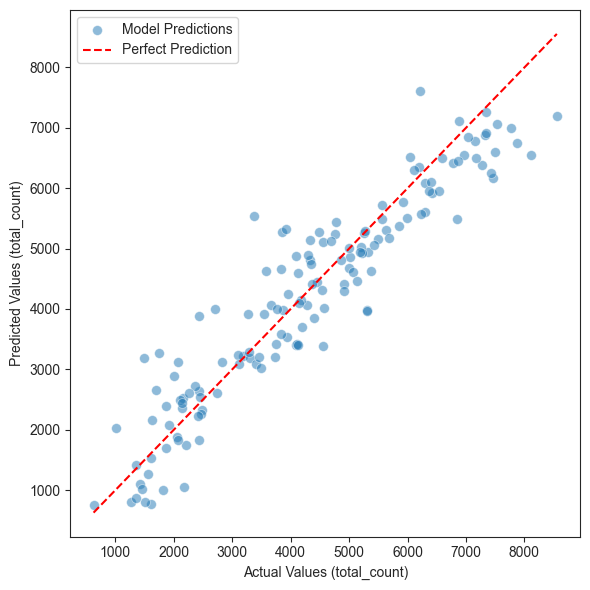

#### **Figure 10:** Actual vs. Predicted Values – Linear Model

In [288]:
# Scatter plot of actual vs predicted values
plt.figure(figsize=(6, 6))

sns.scatterplot(x=y_test_lin, y=y_pred_lin, alpha=0.5, s=50, label='Model Predictions')

lims = [
    min(y_test_lin.min(), y_pred_lin.min()),
    max(y_test_lin.max(), y_pred_lin.max())
]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Values (total_count)')
plt.ylabel('Predicted Values (total_count)')
#plt.title('Actual vs. Predicted Values – Linear Model')
plt.legend()
plt.tight_layout()
plt.show()
display(Markdown("#### **Figure 10:** Actual vs. Predicted Values – Linear Model"))


In the exploratory data analysis in section 2.2.1, we identified clear non-linear relationships between the numerical predictors, particularly temperature and humidity, and the target variable total_count. The initial linear regression model, while performing well, is inherently limited by its assumption of a straight-line relationship and thus cannot fully capture these observed curves.

To address this limitation and potentially improve the model's predictive accuracy, we now extend the linear regression approach by incorporating polynomial features. By creating new features that include squared terms (e.g., temperature²) and interaction terms (e.g., temperature * humidity), we enable the linear model to fit a more flexible, curved surface to the data. This approach allows the model to better represent the diminishing returns of rising temperatures and the optimal comfort zones for humidity that were previously identified. The same forward stepwise selection methodology is then applied to this new, expanded set of features to determine which of these linear, quadratic, and interaction terms are most impactful, with the goal of building a more powerful and accurate model.

Total number of features after polynomial expansion and encoding: 34
Step 0: Null Model MSE = 3759829.36
Step 1: Added 'temperature', CV MSE: 2263824.68
Step 2: Added 'year_1', CV MSE: 1245966.82
Step 3: Added 'temperature^2', CV MSE: 1074536.61
Step 4: Added 'humidity windspeed', CV MSE: 841555.28
Step 5: Added 'humidity^2', CV MSE: 766059.94
Step 6: Added 'season_4', CV MSE: 709815.61
Step 7: Added 'weathersit_3', CV MSE: 688428.56
Step 8: Added 'month_9', CV MSE: 669573.55
Step 9: Added 'weathersit_2', CV MSE: 655778.57
Step 10: Added 'season_2', CV MSE: 643187.40
Step 11: Added 'season_3', CV MSE: 612377.55
Step 12: Added 'humidity', CV MSE: 599627.04
Step 13: Added 'month_4', CV MSE: 589357.24
Step 14: Added 'holiday_1', CV MSE: 584806.37
Step 15: Added 'month_10', CV MSE: 579632.28
Step 16: Added 'weekday_6', CV MSE: 576706.71
Step 17: Added 'workingday_1', CV MSE: 566724.28
Step 18: Added 'month_3', CV MSE: 564399.70
Step 19: Added 'windspeed', CV MSE: 562578.75
Step 20: Added '

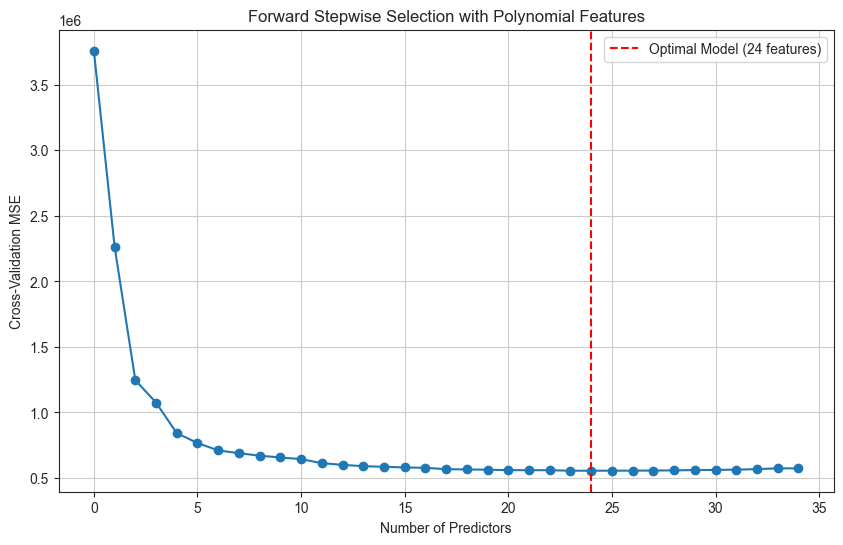

In [289]:
# --- 1. Data Preparation with Polynomial Features ---

# Drop columns that are not needed or would cause data leakage
df_model_poly = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'], errors='ignore')
X_poly = df_model_poly.drop('total_count', axis=1)
y_poly = df_model_poly['total_count']
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)
# Define feature types
categorical_features_poly = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_poly = [col for col in X_poly.columns if col not in categorical_features_poly]


# Create a new pipeline for numerical features that first creates polynomial features
# and then scales them.
# Include_bias=False prevents adding a column of ones (the intercept is handled by LinearRegression).
numerical_pipeline_poly = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Update the preprocessor to use the new numerical pipeline
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_poly, numerical_features_poly),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_poly)
    ],
    remainder='passthrough'
)

# Fit the preprocessor and get the complete list of new feature names
preprocessor_poly.fit(X_poly)
poly_names = preprocessor_poly.named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_poly)
ohe_names_poly = preprocessor_poly.named_transformers_['cat'].get_feature_names_out(categorical_features_poly)
all_names_poly = list(poly_names) + list(ohe_names_poly)

print(f"Total number of features after polynomial expansion and encoding: {len(all_names_poly)}")


# --- 2. Run Forward Stepwise Selection (using the same function as before) ---
# The function is called with the new preprocessor and the expanded feature list
history_df_poly, best_features_poly = forward_stepwise_selection(X_train_poly, y_train_poly, preprocessor_poly, all_names_poly, cv_folds=5)


# --- 3. Visualize Selection Process ---
plt.figure(figsize=(10, 6))
plt.plot(history_df_poly['num_features'], history_df_poly['cv_mse'], marker='o', linestyle='-')
best_num_features_poly = history_df_poly['cv_mse'].idxmin()
plt.axvline(x=best_num_features_poly, color='r', linestyle='--', label=f'Optimal Model ({best_num_features_poly} features)')
plt.xlabel('Number of Predictors')
plt.ylabel('Cross-Validation MSE')
plt.title('Forward Stepwise Selection with Polynomial Features')
plt.legend()
plt.grid(True)
plt.show()

The forward stepwise selection process was then applied to this expanded feature set. The algorithm iteratively added features, significantly reducing the cross-validated Mean Squared Error (MSE) from an initial null model MSE of over 3.7 million. Key features like ``temperature``, ``year_1``, and the new ``temperature²`` term provided the most substantial initial error reductions. The process continued until it identified an optimal model with 24 features, achieving the lowest CV MSE of approximately 554743. After this point, adding more features began to increase the cross-validation error, indicating that the model was starting to overfit.


--- Evaluating Final Polynomial Model on a Hold-Out Test Set ---
Features in the final model: ['temperature', 'year_1', 'temperature^2', 'humidity windspeed', 'humidity^2', 'season_4', 'weathersit_3', 'month_9', 'weathersit_2', 'season_2', 'season_3', 'humidity', 'month_4', 'holiday_1', 'month_10', 'weekday_6', 'workingday_1', 'month_3', 'windspeed', 'windspeed^2', 'temperature windspeed', 'month_11', 'month_12', 'month_2']
Test Set MSE: 426632.65
Test Set RMSE: 653.17
Test Set MAE: 508.56
Test Set R-squared (R²): 0.8804


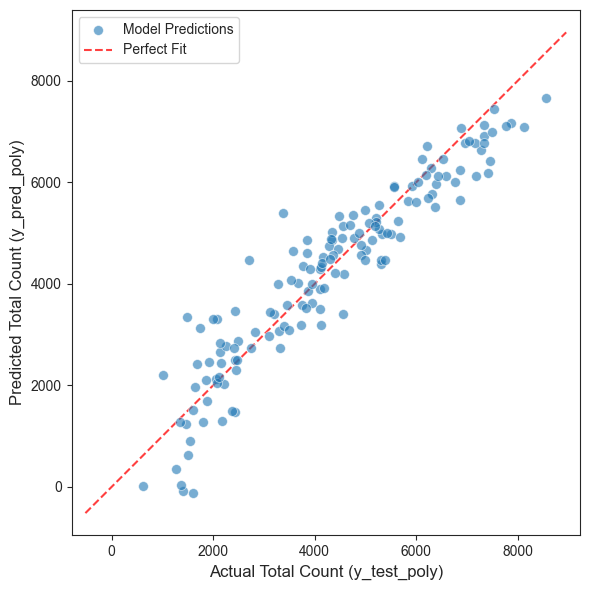

#### **Figure 11:** Actual vs. Predicted Values – Polynomial Model

In [290]:
# --- 4. Final Model Evaluation on a Test Set ---
print("\n--- Evaluating Final Polynomial Model on a Hold-Out Test Set ---")

# Create the final pipeline with the best features identified
final_indices_poly = [all_names_poly.index(f) for f in best_features_poly]
final_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('selector', ColumnTransformer([('selector', 'passthrough', final_indices_poly)], remainder='drop')),
    ('regressor', LinearRegression())
])

final_pipeline_poly.fit(X_train_poly, y_train_poly)
y_pred_poly = final_pipeline_poly.predict(X_test_poly)
test_mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
test_mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)

print(f"Features in the final model: {best_features_poly}")
print(f"Test Set MSE: {test_mse_poly:.2f}")
print(f"Test Set RMSE: {np.sqrt(test_mse_poly):.2f}")
print(f"Test Set MAE: {test_mae_poly:.2f}")

# Calculate and print R-squared score
r2_poly = final_pipeline_poly.score(X_test_poly, y_test_poly)
print(f"Test Set R-squared (R²): {r2_poly:.4f}")


plt.figure(figsize=(6, 6))

# Create the scatter plot of actual vs. predicted values
sns.scatterplot(x=y_test_poly, y=y_pred_poly, alpha=0.6, s=50, label='Model Predictions')

# Add the line of perfect fit (y=x) for reference
# We find the min and max of the axes to draw a diagonal line across the plot
lims = [
    np.min([plt.gca().get_xlim(), plt.gca().get_ylim()]),
    np.max([plt.gca().get_xlim(), plt.gca().get_ylim()]),
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Fit')

# Set labels and title for clarity
plt.xlabel("Actual Total Count (y_test_poly)", fontsize=12)
plt.ylabel("Predicted Total Count (y_pred_poly)", fontsize=12)
#plt.title("Actual vs. Predicted Values for Final Polynomial Model", fontsize=14)
plt.legend()
plt.axis('equal') # Ensures the x and y axes have the same scale for a proper 45-degree linel') # Ensures the x and y axes
plt.tight_layout()
plt.show()
display(Markdown("#### **Figure 11:** Actual vs. Predicted Values – Polynomial Model"))


To quantify the benefit of capturing the non-linear effects identified earlier, the final model incorporating polynomial features was evaluated on the hold-out test set. The results confirm a substantial leap in predictive power. This enhanced model achieved an exceptional Test Set R-squared (R²) of 0.8804, meaning it successfully explains 88% of the variance in daily bike rentals—a significant increase compared to the simple linear model. This improvement is also reflected in the error metrics, with the RMSE dropping to 653.17 and the MAE to 508.56, indicating a considerable reduction in the average prediction error. The strong performance is visually underscored by the actual vs. predicted plot (see Figure 11), where the data points now cluster even more tightly around the line of perfect prediction, demonstrating the model's high degree of accuracy.

### 3.2 Ridge Regression 

While adding polynomial features significantly improved the predictive accuracy of the linear model, it also drastically increased the number of predictors. A model with such a high number of features becomes susceptible to **overfitting**, where it learns the noise in the training data too well and may not generalize effectively to new, unseen data.

To address this challenge, we now turn to **Ridge Regression**. This model is an extension of linear regression that incorporates **L2 regularization**, a technique specifically designed to combat overfitting. Ridge Regression works by adding a penalty term to the model's loss function that is proportional to the sum of the squared coefficients. This penalty "shrinks" the coefficients towards zero, discouraging the model from assigning excessive weight to any single feature. The strength of this penalty is controlled by a hyperparameter, **alpha ($ \alpha $)**. A larger alpha results in greater shrinkage and a simpler model.

The goal of this section is to use cross-validation to systematically find the optimal value for alpha that balances the trade-off between model fit and complexity, thereby creating a model that is not only accurate but also more robust.

--- Starting GridSearchCV for Ridge Regression ---
GridSearchCV finished. Best alpha found: 0.0534


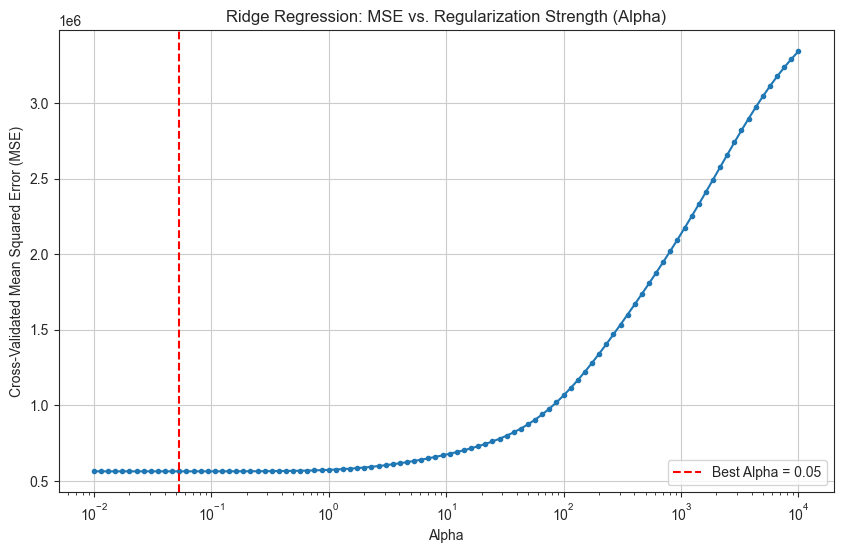

#### **Figure 12:** Ridge Regression: MSE vs. Regularization Strength (``alpha``)


--- Calculating and plotting coefficient paths ---


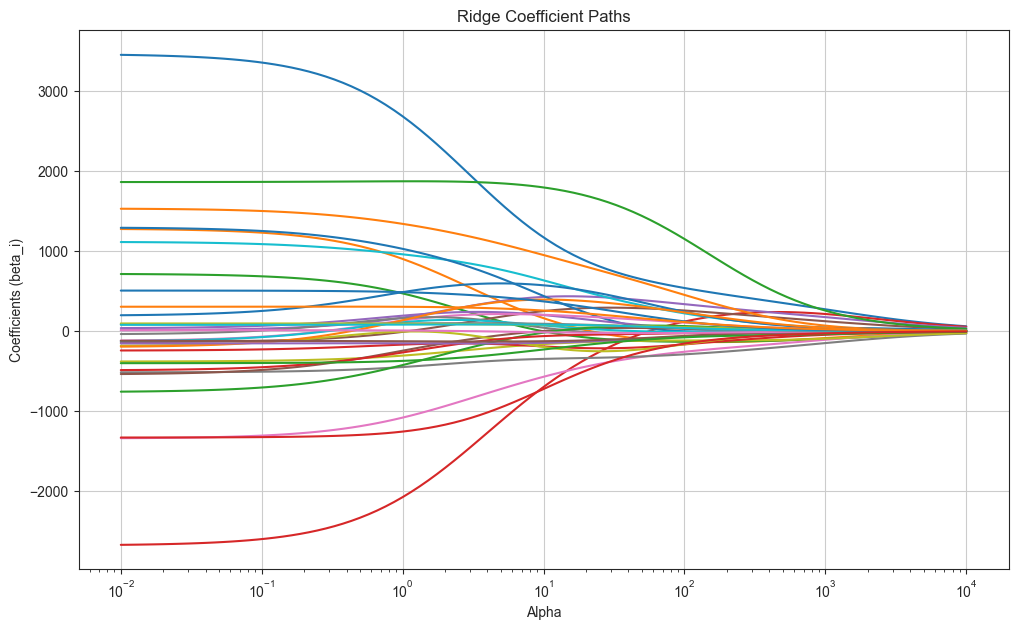

#### **Figure 13:** Ridge Coefficient Paths


--- Training and Evaluating Final Model with the best Alpha: 0.0534 ---
Test Set MSE: 424685.92
Test Set RMSE: 651.68
Test Set MAE: 504.81
Test Set R-squared (R²): 0.8810


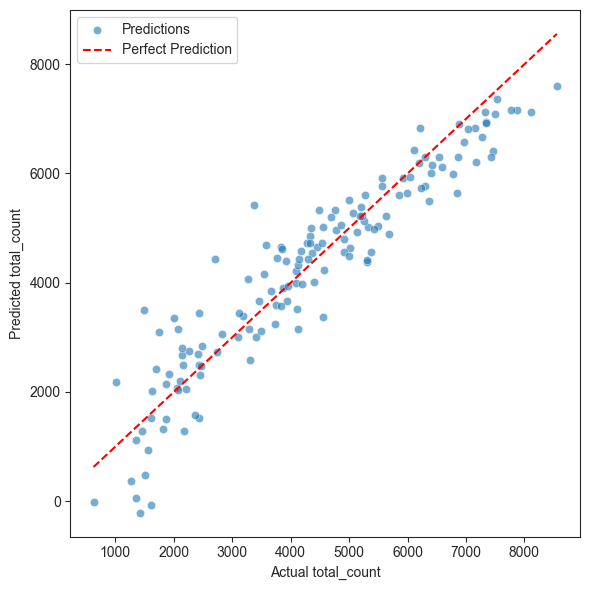

#### **Figure 14:** Actual vs. Predicted – Final Ridge Model

#### **Table 16:** Coefficients of the Final Lasso Model

temperature              3405.917461
year_1                   1864.642618
season_4                 1515.842024
season_3                 1271.930999
humidity                 1254.026558
season_2                 1100.649453
windspeed                 700.098773
weekday_6                 506.453827
workingday_1              305.556527
month_9                   226.237813
weekday_4                  96.209261
weekday_3                  86.086168
weekday_5                  79.621278
month_3                    53.043899
temperature humidity       22.019420
weekday_2                  12.058793
month_6                   -13.190227
month_5                   -92.639014
month_8                   -98.628712
weekday_1                -121.084179
temperature windspeed    -128.481507
holiday_1                -152.665206
month_7                  -158.968993
month_10                 -166.376938
month_2                  -234.559698
windspeed^2              -374.673180
weathersit_2             -398.862041
m

In [291]:
# --- 1. Data and Pipeline Preparation ---

# Drop columns that are not needed or would cause data leakage
# Ensure 'humidity2' is dropped if it exists from previous cells
df_model_ridge = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'], errors='ignore')


# Define features (X) and target (y)
X_ridge = df_model_ridge.drop('total_count', axis=1)
y_ridge = df_model_ridge['total_count']
X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(X_ridge, y_ridge, test_size=0.2, random_state=42)

# Define feature types
categorical_features_ridge = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_ridge = [col for col in X_ridge.columns if col not in categorical_features_ridge]

# Create a pipeline for numerical features: PolynomialFeatures -> StandardScaler
numerical_pipeline_ridge = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Create the main preprocessor
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_ridge, numerical_features_ridge),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_ridge)
    ],
    remainder='passthrough'
)

# Create the full pipeline with Ridge regression
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_ridge),
    ('ridge', Ridge())
])


# --- 2. Grid Search with Cross-Validation to find the best Alpha ---

# Define the grid of alpha values to search
# Using a logarithmic scale is common for regularization parameters
alphas = np.logspace(-2, 4, 100)

# Set up GridSearchCV
# The parameter to tune is 'ridge__alpha' (pipeline-step__parameter)
param_grid = {'ridge__alpha': alphas}
cv_strategy = KFold(n_splits=7, shuffle=True, random_state=42)

print("--- Starting GridSearchCV for Ridge Regression ---")
grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=cv_strategy,
                           scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_ridge, y_train_ridge)

print(f"GridSearchCV finished. Best alpha found: {grid_search.best_params_['ridge__alpha']:.4f}")
best_alpha = grid_search.best_params_['ridge__alpha']


# --- 3. Visualization of Grid Search Results ---

# Plot 1: MSE vs. Alpha
# Shows how model error (MSE) changes with different regularization strengths to choose the best alpha.
plt.figure(figsize=(10, 6))
cv_mse = -grid_search.cv_results_['mean_test_score']
plt.plot(alphas, cv_mse, marker='.')
plt.xscale('log')
plt.axvline(best_alpha, linestyle='--', color='r', label=f'Best Alpha = {best_alpha:.2f}')
plt.xlabel('Alpha')
plt.ylabel('Cross-Validated Mean Squared Error (MSE)')
plt.title('Ridge Regression: MSE vs. Regularization Strength (Alpha)')
plt.legend()
plt.grid(True)
plt.show()
display(Markdown("#### **Figure 12:** Ridge Regression: MSE vs. Regularization Strength (``alpha``)"))


# Plot 2: Coefficients as a function of Alpha (Coefficient Path)
# Visualizes how Ridge coefficients shrink smoothly under increasing regularization.
print("\n--- Calculating and plotting coefficient paths ---")
coefs = []
for a in alphas:
    ridge_pipeline.set_params(ridge__alpha=a)
    ridge_pipeline.fit(X_train_ridge, y_train_ridge)
    coefs.append(ridge_pipeline.named_steps['ridge'].coef_)

plt.figure(figsize=(12, 7))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients (beta_i)')
plt.title('Ridge Coefficient Paths')
plt.axis('tight')
plt.grid(True)
plt.show()
display(Markdown("#### **Figure 13:** Ridge Coefficient Paths"))


# --- 4. Final Model with Optimal Alpha ---

print(f"\n--- Training and Evaluating Final Model with the best Alpha: {best_alpha:.4f} ---")


# Create the final pipeline with the best alpha
final_ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_ridge),
    ('ridge', Ridge(alpha=best_alpha))
])

# Fit the model on the training data
final_ridge_pipeline.fit(X_train_ridge, y_train_ridge)

# Evaluate on the test data
y_pred_ridge = final_ridge_pipeline.predict(X_test_ridge)
test_mse_ridge = mean_squared_error(y_test_ridge, y_pred_ridge)
test_rmse_ridge = np.sqrt(test_mse_ridge)
test_mae_ridge = mean_absolute_error(y_test_ridge, y_pred_ridge) 
r2_ridge = final_ridge_pipeline.score(X_test_ridge, y_test_ridge)

print(f"Test Set MSE: {test_mse_ridge:.2f}")
print(f"Test Set RMSE: {test_rmse_ridge:.2f}")
print(f"Test Set MAE: {test_mae_ridge:.2f}")
print(f"Test Set R-squared (R²): {r2_ridge:.4f}")

# Plot 3: Scatter plot of actual vs predicted values using Seaborn
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_ridge, y=y_pred_ridge, alpha=0.6, label='Predictions')
sns.lineplot(x=y_test_ridge, y=y_test_ridge, color='red', linestyle='--', label='Perfect Prediction')  
plt.xlabel('Actual total_count')
plt.ylabel('Predicted total_count')
#plt.title('Actual vs. Predicted – Final Ridge Model')
plt.legend()
plt.tight_layout()
plt.show()
display(Markdown("#### **Figure 14:** Actual vs. Predicted – Final Ridge Model"))



# --- 5. Display Coefficients of the Final Model ---

# Get feature names from the preprocessor after it has been fitted
poly_feature_names = final_ridge_pipeline.named_steps['preprocessor'].named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_ridge)
ohe_feature_names = final_ridge_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_ridge)
all_feature_names = list(poly_feature_names) + list(ohe_feature_names)

# Get the coefficients from the fitted ridge model
final_coefs = final_ridge_pipeline.named_steps['ridge'].coef_

# Create a pandas Series for better display
coef_series = pd.Series(final_coefs, index=all_feature_names)

display(Markdown("#### **Table 16:** Coefficients of the Final Lasso Model"))
with pd.option_context('display.max_rows', None):
    display(coef_series.sort_values(ascending=False))

The hyperparameter tuning for the Ridge Regression model was performed using GridSearchCV to find the optimal regularization strength ``lambda ``. The cross-validation results show that the model achieves the lowest Mean Squared Error (MSE) at a relatively small lambda  value of approximately 0.05 as indicated in Figure 12. This indicates that while some regularization is beneficial, a strong penalty is not required, suggesting the model benefits from retaining the complexity of the polynomial features.

After identifying the optimal regularization strength (alpha ≈ 0.05), the final Ridge model was trained and evaluated on the hold-out test set. The model achieved a Test Set R-squared (R²) of 0.881, indicating it explains 88.1% of the variance in the test data. The error metrics, an RMSE of 651.68 and an MAE of 504.81, are very similar to the performance of the initial linear model that used forward selection. The final model contains a total of 34 variables, with the coefficients shown in Table 16.

This result implies that at the optimal alpha, the L2 regularization penalized the complex polynomial and interaction terms heavily, effectively nullifying their benefit and resulting in a model with a similar performance to the simpler linear version.


### 3.3 LASSO Regression

While Ridge Regression is effective at preventing overfitting by shrinking coefficients, it retains all features in the final model. We now turn to **Lasso Regression**, an alternative and powerful regularization technique.

Lasso utilizes **L1 regularization**, which adds a penalty proportional to the absolute value of the coefficients. A key consequence of this penalty is that it can force the coefficients of less important features to become **exactly zero**. This unique property means that Lasso performs automatic feature selection, producing a more parsimonious and potentially more interpretable model. The objective of this section is to apply Lasso regression and tune its regularization strength, alpha ($\alpha$), to see if it can achieve a high level of predictive accuracy while simplifying the model by eliminating unneeded features.

--- Starting GridSearchCV for Lasso Regression ---
GridSearchCV finished. Best alpha found: 0.7221


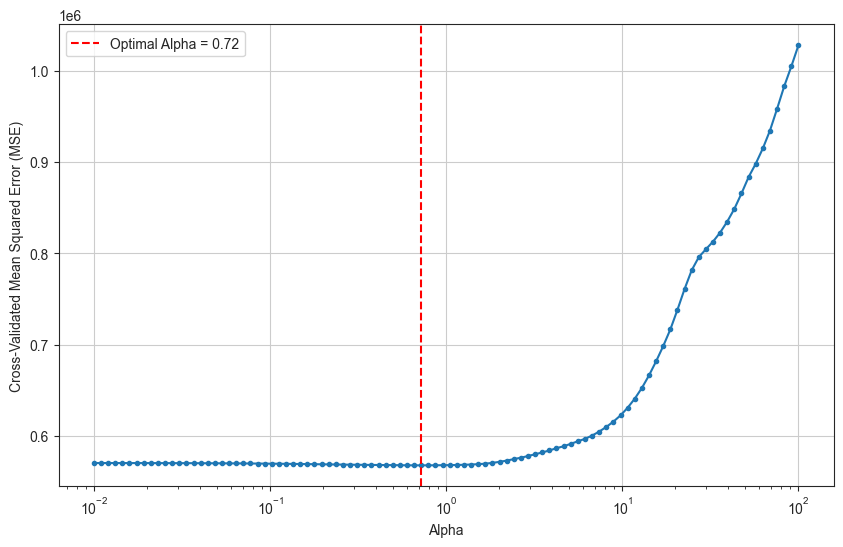

#### **Figure 15:** Lasso Regression: MSE vs. Regularization Strength (``alpha``)


--- Calculating and plotting coefficient paths for Lasso ---


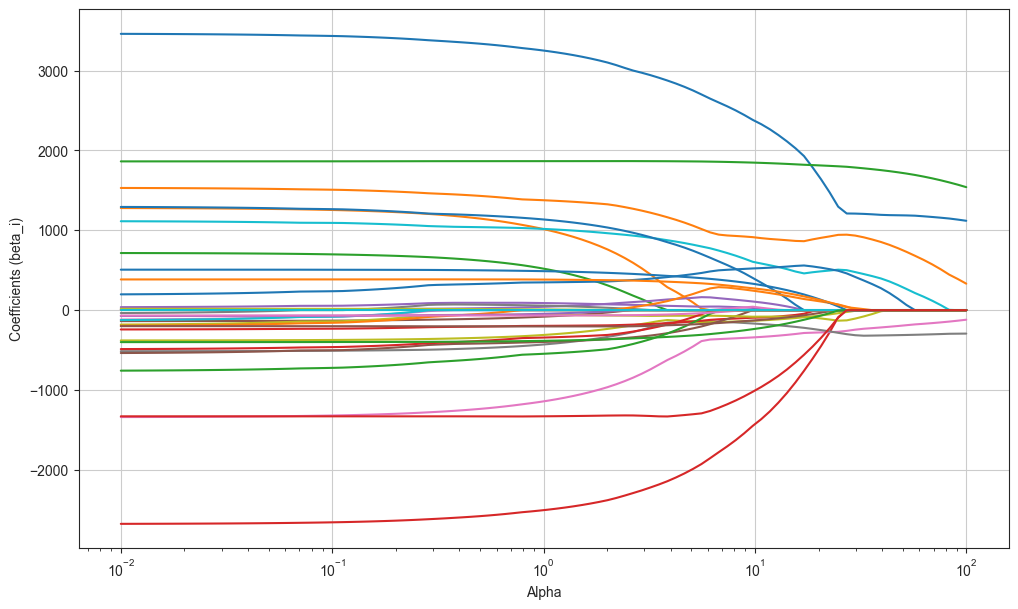

#### **Figure 16:** Lasso Coefficient Paths

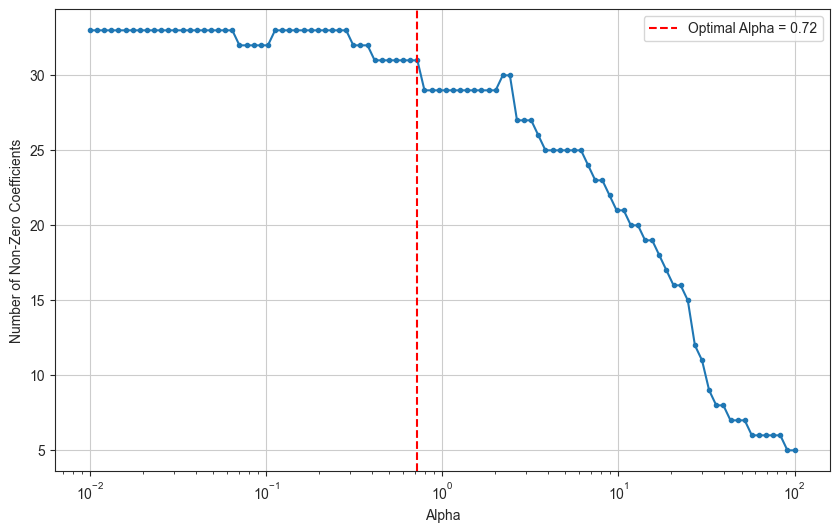

#### **Figure 17:** Lasso Regression: Number of Selected Features vs. Regularization Strength (``alpha``)


--- Training and Evaluating Final Lasso Model with Optimal Alpha: 0.7221 ---
Test Set MSE: 416801.90
Test Set RMSE: 645.60
Test Set MAE: 501.32
Test Set R-squared (R²): 0.8832


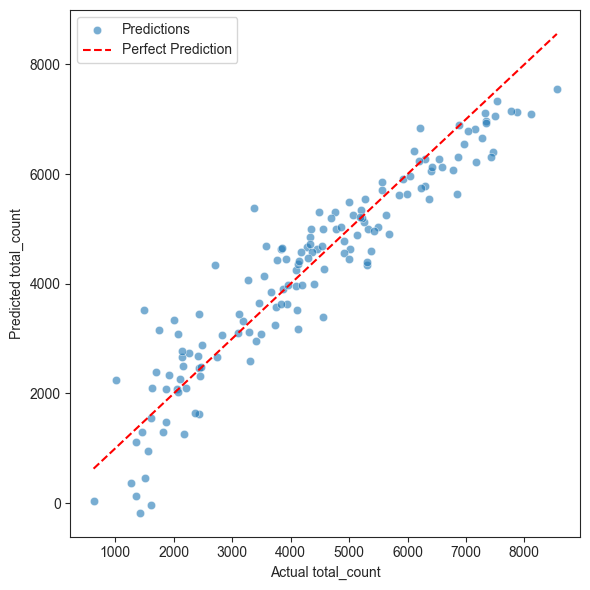

#### **Figure 18:** Actual vs. Predicted – Final Lasso Model

#### **Table 17:** Coefficients of the Final Lasso Model

temperature              3295.715892
year_1                   1866.372260
season_4                 1397.463944
season_3                 1164.124242
humidity                 1086.941498
season_2                 1031.344017
windspeed                 577.309384
weekday_6                 494.351404
workingday_1              384.770843
month_9                   341.997393
month_3                    92.325364
month_6                    63.578363
temperature humidity       32.150371
weekday_4                  10.745308
weekday_3                   0.653512
month_10                  -10.237977
holiday_1                 -53.456424
month_7                   -58.973357
weekday_2                 -67.150507
temperature windspeed     -95.924759
month_2                  -199.532169
weekday_1                -203.665657
windspeed^2              -331.102137
month_12                 -357.960612
weathersit_2             -389.188776
month_4                  -408.204720
humidity windspeed       -455.923269
m

In [292]:
# --- 1. Data and Pipeline Preparation for Lasso ---

# Drop columns that are not needed or would cause data leakage
df_model_lasso = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant'], errors='ignore')
if 'humidity2' in df_model_lasso.columns:
    df_model_lasso = df_model_lasso.drop(columns=['humidity2'])

# Define features (X_lasso) and target (y_lasso)
X_lasso = df_model_lasso.drop('total_count', axis=1)
y_lasso = df_model_lasso['total_count']
# Split data into training and test sets
X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(X_lasso, y_lasso, test_size=0.2, random_state=42)

# Define feature types
categorical_features_lasso = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_lasso = [col for col in X_lasso.columns if col not in categorical_features_lasso]

# Create a pipeline for numerical features: PolynomialFeatures -> StandardScaler
numerical_pipeline_lasso = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Create the main preprocessor for Lasso
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_lasso, numerical_features_lasso),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_lasso)
    ],
    remainder='passthrough'
)

# Create the full pipeline with Lasso regression
# Increased max_iter to prevent convergence warnings with many features
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lasso),
    ('lasso', Lasso(max_iter=10000))
])


# --- 2. Grid Search with Cross-Validation to find the best Alpha ---

# Define the grid of alpha values to search
alphas_lasso = np.logspace(-2, 2, 100)

# Set up GridSearchCV for Lasso
param_grid_lasso = {'lasso__alpha': alphas_lasso}
cv_strategy_lasso = KFold(n_splits=7, shuffle=True, random_state=0)

print("--- Starting GridSearchCV for Lasso Regression ---")
grid_search_lasso = GridSearchCV(lasso_pipeline, param_grid_lasso, cv=cv_strategy_lasso,
                                 scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lasso.fit(X_train_lasso, y_train_lasso)

print(f"GridSearchCV finished. Best alpha found: {grid_search_lasso.best_params_['lasso__alpha']:.4f}")
best_alpha_lasso = grid_search_lasso.best_params_['lasso__alpha']


# --- 3. Visualization of Grid Search Results ---

# Plot 1: MSE vs. Alpha
# Shows how model error (MSE) changes with different regularization strengths to choose the best alpha.
plt.figure(figsize=(10, 6))
cv_mse_lasso = -grid_search_lasso.cv_results_['mean_test_score']
plt.plot(alphas_lasso, cv_mse_lasso, marker='.')
plt.xscale('log')
plt.axvline(best_alpha_lasso, linestyle='--', color='r', label=f'Optimal Alpha = {best_alpha_lasso:.2f}')
plt.xlabel('Alpha')
plt.ylabel('Cross-Validated Mean Squared Error (MSE)')
#plt.title('Lasso Regression: MSE vs. Regularization Strength (Aplpha)')
plt.legend()
plt.grid(True)
plt.show()
display(Markdown("#### **Figure 15:** Lasso Regression: MSE vs. Regularization Strength (``alpha``)"))


# Plot 2: Coefficients as a function of Alpha (Coefficient Path)
# Shows how Lasso drives some coefficients to exactly zero as regularization increases.
print("\n--- Calculating and plotting coefficient paths for Lasso ---")
coefs_lasso = []
for a in alphas_lasso:
    lasso_pipeline.set_params(lasso__alpha=a)
    lasso_pipeline.fit(X_train_lasso, y_train_lasso)
    coefs_lasso.append(lasso_pipeline.named_steps['lasso'].coef_)

plt.figure(figsize=(12, 7))
ax = plt.gca()
ax.plot(alphas_lasso, coefs_lasso)
ax.set_xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients (beta_i)')
#plt.title('Lasso Coefficient Paths')
plt.axis('tight')
plt.grid(True)
plt.show()
display(Markdown("#### **Figure 16:** Lasso Coefficient Paths"))

# Plot 3: Number of non-zero coefficients vs. Alpha
# Plot the number of non-zero coefficients to visualize Lasso's feature selection ability.
non_zero_coefs = [np.sum(np.abs(c) > 1e-6) for c in coefs_lasso]
plt.figure(figsize=(10, 6))
plt.plot(alphas_lasso, non_zero_coefs, marker='.')
plt.xscale('log')
plt.axvline(best_alpha_lasso, linestyle='--', color='r', label=f'Optimal Alpha = {best_alpha_lasso:.2f}')
plt.xlabel('Alpha')
plt.ylabel('Number of Non-Zero Coefficients')
#plt.title('Lasso Regression: Number of Selected Features vs. Alpha')
plt.legend()
plt.grid(True)
plt.show()
display(Markdown("#### **Figure 17:** Lasso Regression: Number of Selected Features vs. Regularization Strength (``alpha``)"))


# --- 4. Final Model with Optimal Alpha ---

print(f"\n--- Training and Evaluating Final Lasso Model with Optimal Alpha: {best_alpha_lasso:.4f} ---")



# Create the final pipeline with the best alpha
final_lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lasso),
    ('lasso', Lasso(alpha=best_alpha_lasso, max_iter=10000))
])

# Fit the model on the training data
final_lasso_pipeline.fit(X_train_lasso, y_train_lasso)

# Evaluate on the test data
y_pred_lasso = final_lasso_pipeline.predict(X_test_lasso)
test_mse_lasso = mean_squared_error(y_test_lasso, y_pred_lasso)
test_rmse_lasso = np.sqrt(test_mse_lasso)
test_mae_lasso = mean_absolute_error(y_test_lasso, y_pred_lasso)
r2_lasso = final_lasso_pipeline.score(X_test_lasso, y_test_lasso)

print(f"Test Set MSE: {test_mse_lasso:.2f}")
print(f"Test Set RMSE: {test_rmse_lasso:.2f}")
print(f"Test Set MAE: {test_mae_lasso:.2f}")
print(f"Test Set R-squared (R²): {r2_lasso:.4f}")

# Plot 4: Scatter plot of actual vs predicted values using Seaborn
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_lasso, y=y_pred_lasso, alpha=0.6, label='Predictions')
sns.lineplot(x=y_test_lasso, y=y_test_lasso, color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual total_count')
plt.ylabel('Predicted total_count')
#plt.title('Actual vs. Predicted – Final Lasso Model')
plt.legend()
plt.tight_layout()
plt.show()
display(Markdown("#### **Figure 18:** Actual vs. Predicted – Final Lasso Model"))


# --- 5. Display Coefficients of the Final Model ---

# Get feature names from the preprocessor after it has been fitted
poly_feature_names_lasso = final_lasso_pipeline.named_steps['preprocessor'].named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_lasso)
ohe_feature_names_lasso = final_lasso_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_lasso)
all_feature_names_lasso = list(poly_feature_names_lasso) + list(ohe_feature_names_lasso)

# Get the coefficients from the fitted lasso model
final_coefs_lasso = final_lasso_pipeline.named_steps['lasso'].coef_

# Create a pandas Series for better display
coef_series_lasso = pd.Series(final_coefs_lasso, index=all_feature_names_lasso)

display(Markdown("#### **Table 17:** Coefficients of the Final Lasso Model"))
with pd.option_context('display.max_rows', None):
    display(coef_series_lasso[coef_series_lasso != 0].sort_values(ascending=False))

A GridSearchCV process was used to find the optimal regularization strength for the Lasso model, identifying a best alpha of approximately 0.72. A visualization of the tuning process shows that the cross-validated MSE is minimized at this alpha. The coefficient path plot (see Figure 17) illustrates a key feature of Lasso, as the regularization strength increases, many feature coefficients are driven to exactly zero. This demonstrates Lasso's ability to perform automatic feature selection.

The final Lasso model, trained with the optimal alpha, was evaluated on the test set. It achieved a Test Set R-squared (R²) of 0.8832, indicating that it explains 88.3% of the variance in the test data. This performance is slightly better than both the initial linear model and the Ridge regression model. The error metrics, an RMSE of 645.60 and an MAE of 501.32, are correspondingly the lowest among the linear models tested so far.

The model selected 29 features, successfully reducing the complexity from the full set of polynomial and interaction terms. This demonstrates Lasso's advantage in creating a more parsimonious model without sacrificing predictive accuracy. The scatter plot of actual versus predicted values confirms the model's strong performance, showing a tight clustering of predictions around the line of perfect fit.

### 3.4 Random Forest Regression

After exploring linear models, we now shift to a fundamentally different and more powerful approach: the **Random Forest Regressor**. Unlike the previous models that rely on a single equation, a Random Forest is an **ensemble method**. It creates a large number of individual decision trees during training and outputs the average of their predictions, using the wisdom of the crowd to produce a more accurate and robust final prediction.

This model is particularly well-suited for our dataset for two key reasons. First, it can natively capture complex, **non-linear relationships** and interactions between features without requiring manual creation of polynomial terms. Second, it is inherently **robust to outliers**, a known characteristic of our data. Random Forests mitigate the influence of individual outliers because each tree sees only a bootstrap sample of the data, and final predictions average over dozens of trees. As a result, any single extreme observation affects only a minority of trees, and its impact is diluted in the ensemble.

To maximize the model's predictive power while preventing overfitting, its structure must be carefully controlled through **hyperparameter tuning**. We employ `GridSearchCV` to systematically explore a grid of parameters and identify the optimal combination based on 7-fold cross-validation. The key hyperparameters tuned in this process include:
* **`n_estimators`**: The number of trees in the forest, tested with values of [100, 150, 200]. More trees generally improve performance but increase computational cost.
* **`max_depth`**: The maximum depth of each tree, tested with [10, 20, None]. This parameter controls the complexity of the trees; `None` allows trees to grow until all leaves are pure.
* **`min_samples_leaf`**: The minimum number of data points required to form a leaf node, tested with [1, 2, 3, 5]. This helps to smooth the model and prevent it from learning noise.
* **`max_features`**: The number of features considered at each split, tested with ['sqrt', 'log2']. This introduces randomness, which helps to decorrelate the trees and reduce variance.
* **`bootstrap`**: Whether data points are sampled with replacement when building trees, tested with both [True, False].

This comprehensive tuning process ensures we find the best possible Random Forest architecture for predicting bike share usage.

--- Starting GridSearchCV for Random Forest ---
Fitting 7 folds for each of 144 candidates, totalling 1008 fits

GridSearchCV finished. Best parameters found: {'regressor__bootstrap': False, 'regressor__max_depth': 20, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 200}

--- Final Random Forest Model Performance ---
Test Set MSE: 373590.05
Test Set RMSE: 611.22
Test Set MAE: 466.89
Test Set R-squared (R²): 0.8953

--- Plotting Feature Importance ---


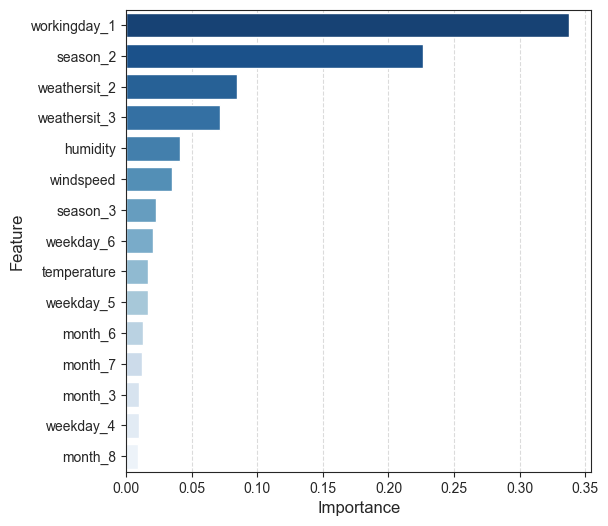

#### **Figure 19:** Top 15 Feature Importances from Random Forest

---

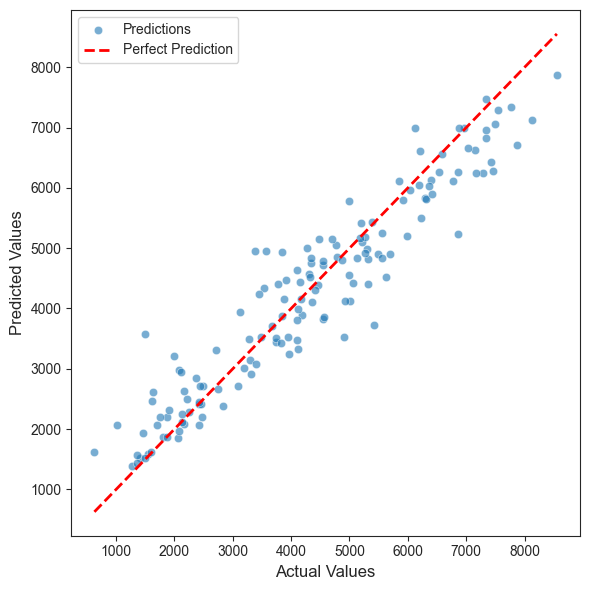

#### **Figure 20:** Random Forest: Actual vs. Predicted Values

In [ ]:
# Analyse Feature importance when applying decision tree


# --- 1. Data Preparation for Random Forest ---

# Use a clean copy of the dataframe
df_model_rf = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'], errors='ignore')

# Define features (X_rf) and target (y_rf)
X_rf = df_model_rf.drop('total_count', axis=1)
y_rf = df_model_rf['total_count']


# Define feature types. For Random Forest, we only need to encode categorical features.
# Scaling numerical features is not necessary.
categorical_features_rf = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_rf = [col for col in X_rf.columns if col not in categorical_features_rf]

# Create a preprocessor that only one-hot encodes categorical features
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_rf)
    ],
    remainder='passthrough'  # Keep numerical columns as they are
)


# --- 2. Pipeline and GridSearchCV Setup ---

# Create the full pipeline with the preprocessor and the RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Define a parameter grid for GridSearchCV. 
param_grid_rf = {
    'regressor__n_estimators': [100, 150, 200],       # Number of trees in the forest
    'regressor__max_depth': [10, 20, None],      # Maximum depth of the tree
    'regressor__min_samples_leaf': [1, 2, 3, 5],       # Minimum number of samples required at a leaf node
    'regressor__max_features': ['sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'regressor__bootstrap': [True, False]  # Test with and without bootstrap sampling
}

# Set up the grid search with 5-fold cross-validation
cv_strategy_rf = KFold(n_splits=7, shuffle=True, random_state=42)

print("--- Starting GridSearchCV for Random Forest ---")
grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=cv_strategy_rf,
                              scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Split data before fitting the grid search to have a final hold-out test set
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

grid_search_rf.fit(X_train_rf, y_train_rf)

print(f"\nGridSearchCV finished. Best parameters found: {grid_search_rf.best_params_}")


# --- 3. Final Model Evaluation ---

# The best estimator is already fitted on the training data
final_rf_model = grid_search_rf.best_estimator_

# Make predictions on the test set
y_pred_rf = final_rf_model.predict(X_test_rf)

# Calculate final metrics
test_mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
test_rmse_rf = np.sqrt(test_mse_rf)
test_mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print("\n--- Final Random Forest Model Performance ---")
print(f"Test Set MSE: {test_mse_rf:.2f}")
print(f"Test Set RMSE: {test_rmse_rf:.2f}")
print(f"Test Set MAE: {test_mae_rf:.2f}") 
print(f"Test Set R-squared (R²): {r2_rf:.4f}")


# --- 4. Visualization ---

# Plot 1: Feature Importance
print("\n--- Plotting Feature Importance ---")

# Get feature names after one-hot encoding
ohe_feature_names_rf = final_rf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_rf)
all_feature_names_rf = numerical_features_rf + list(ohe_feature_names_rf)

# Get importances from the trained model
importances = final_rf_model.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'feature': all_feature_names_rf, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15) # Top 15 features

plt.figure(figsize=(6, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='Blues_r', hue='feature', legend=False)
#plt.title('Top 15 Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
display(Markdown("#### **Figure 19:** Top 15 Feature Importances from Random Forest"))
display(Markdown("---"))

# Plot 2: Actual vs. Predicted Values
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_rf, y=y_pred_rf, alpha=0.6, label='Predictions')
plt.plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], '--r', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
#plt.title('Random Forest: Actual vs. Predicted Values', fontsize=16)
plt.tight_layout()
plt.legend() 
plt.show()
display(Markdown("#### **Figure 20:** Random Forest: Actual vs. Predicted Values"))

Following a comprehensive hyperparameter search using `GridSearchCV`, the optimal configuration for the Random Forest model was identified. The best-performing model consists of 200 trees, each with a maximum depth of 20, and uses the square root of the total features at each split. This tuned model was then evaluated on the test set to assess its predictive performance.

The final model achieved an excellent **Test Set R-squared (R²) of 0.8953**, indicating that it successfully explains approximately 89.5% of the variance in daily bike rentals. The error metrics are correspondingly low, with a **Root Mean Squared Error (RMSE) of 611.22** and a **Mean Absolute Error (MAE) of 466.89**. While these results are very strong and represent an improvement over the linear regression, Ridge and Lasso regression models.

A key advantage of the Random Forest is its ability to provide feature importances (see Figure 19), which reveal the primary drivers of its predictions. The analysis of this model offers two main insights.
First, the distinction between a working day and a non-working day is most significant. The ``workingday_1`` characteristic has the greatest significance, suggesting that commuter behavior is the single most important factor in predicting daily occupancy rates. This means that policies targeting commuters, such as managing availability in business districts on weekdays, would likely have the greatest impact on the system.
Second, the weather signals are multi-layered. The categorical feature for general weather conditions (`weathersit`) explains more of the variance than the individual numerical metrics like `humidity` or `windspeed`. The high importance of `weathersit_2` (Mist/Cloudy) and `weathersit_3` (Light Snow/Rain) indicates that the decision to ride is heavily influenced by the presence of adverse weather. While these general conditions are most important, the finer numerical variables still provide additional predictive lift.

The scatter plot, illustrated in Figure 20, of actual versus predicted values visually confirms the model's strong generalization capabilities. For the vast majority of operating conditions, the predictions are tightly and unbiasedly clustered around the line of perfect fit. A closer inspection reveals a slight tendency for the model to under-predict on the highest-demand days. Above approximately 7000 actual rides, the points begin to drift just below the line.
Overall, the tuned Random-Forest model delivers strong, reliable forecasts that capture nearly 90 % of the variance in daily bike-sharing demand while providing clear guidance on the most influential drivers of usage.


## 4. Model Comparison

After constructing five distinct regression models in the previous chapter, this section provides a holistic comparison to determine the most effective approach for this prediction task. The analysis goes beyond simple performance metrics to investigate the underlying behavior and feature utilization of each model, providing a basis for selecting a final model on a comprehensive view of its accuracy, interpretability, and robustness.

The comparison is structured in three main parts. First, the predictive performance of all models is benchmarked on the unified test set. Standard regression metrics, including Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the R-squared (R²), are visualized to provide a clear, high-level summary of their accuracy.

Second, a detailed residual analysis is conducted for each model. By plotting the distribution of errors and visualizing the residuals against the predicted values, we can assess the statistical soundness of each model. This helps to identify any systematic biases or patterns in the errors that might persist even in the final models.

Finally, a comprehensive feature importance and selection analysis is performed. A heatmap is generated to visualize which features were selected or deemed most important by each algorithm from the forward selection methods, to Lasso's regularization, to the Random Forest's impurity based importance. This provides deep insight into how each model "thinks," revealing which predictors are consistently identified as crucial and which are unique to a particular modeling approach. This final step allows for a more nuanced conclusion about not just which model is most accurate, but also which provides the most plausible and interpretable solution.

--- Visual Comparison of Model Metrics ---


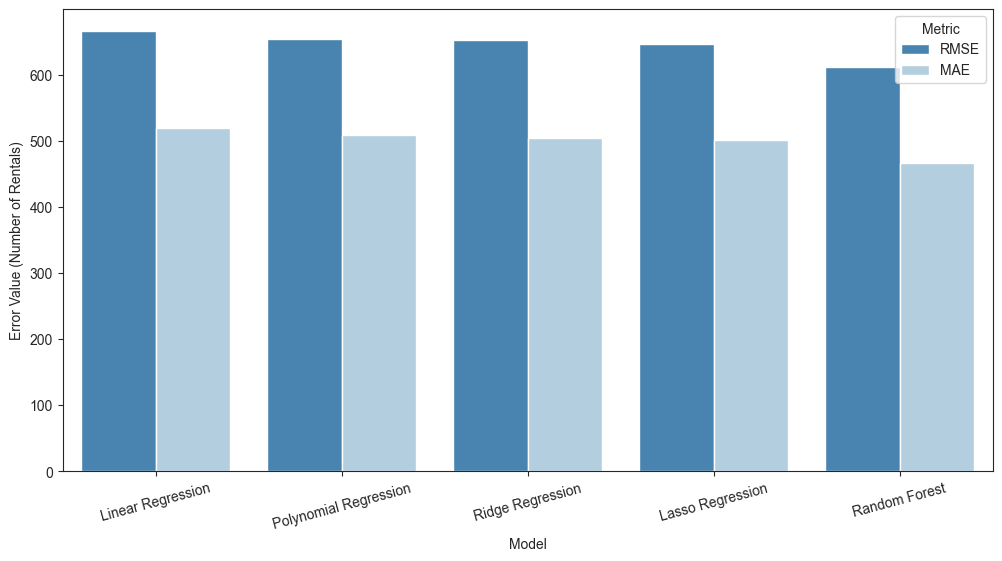

#### **Figure 21:** Comparison of Model Errors (RMSE & MAE)

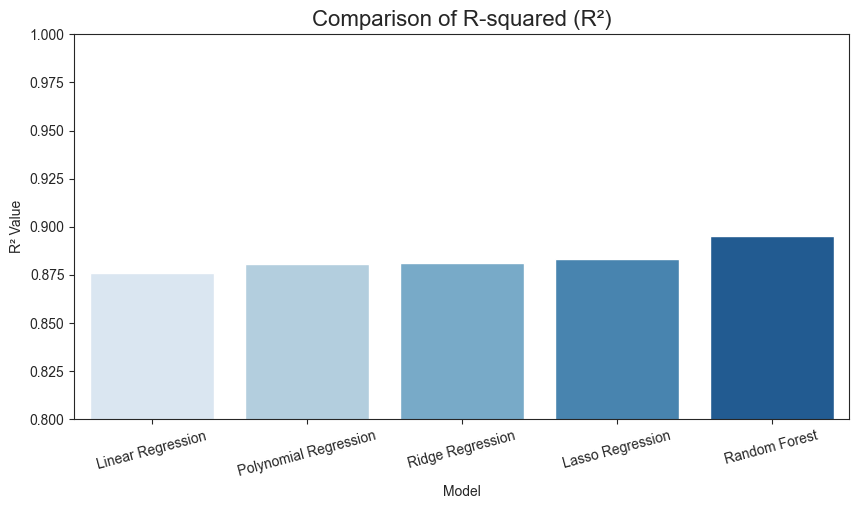

#### **Figure 22:** Comparison of R-squared (R²)

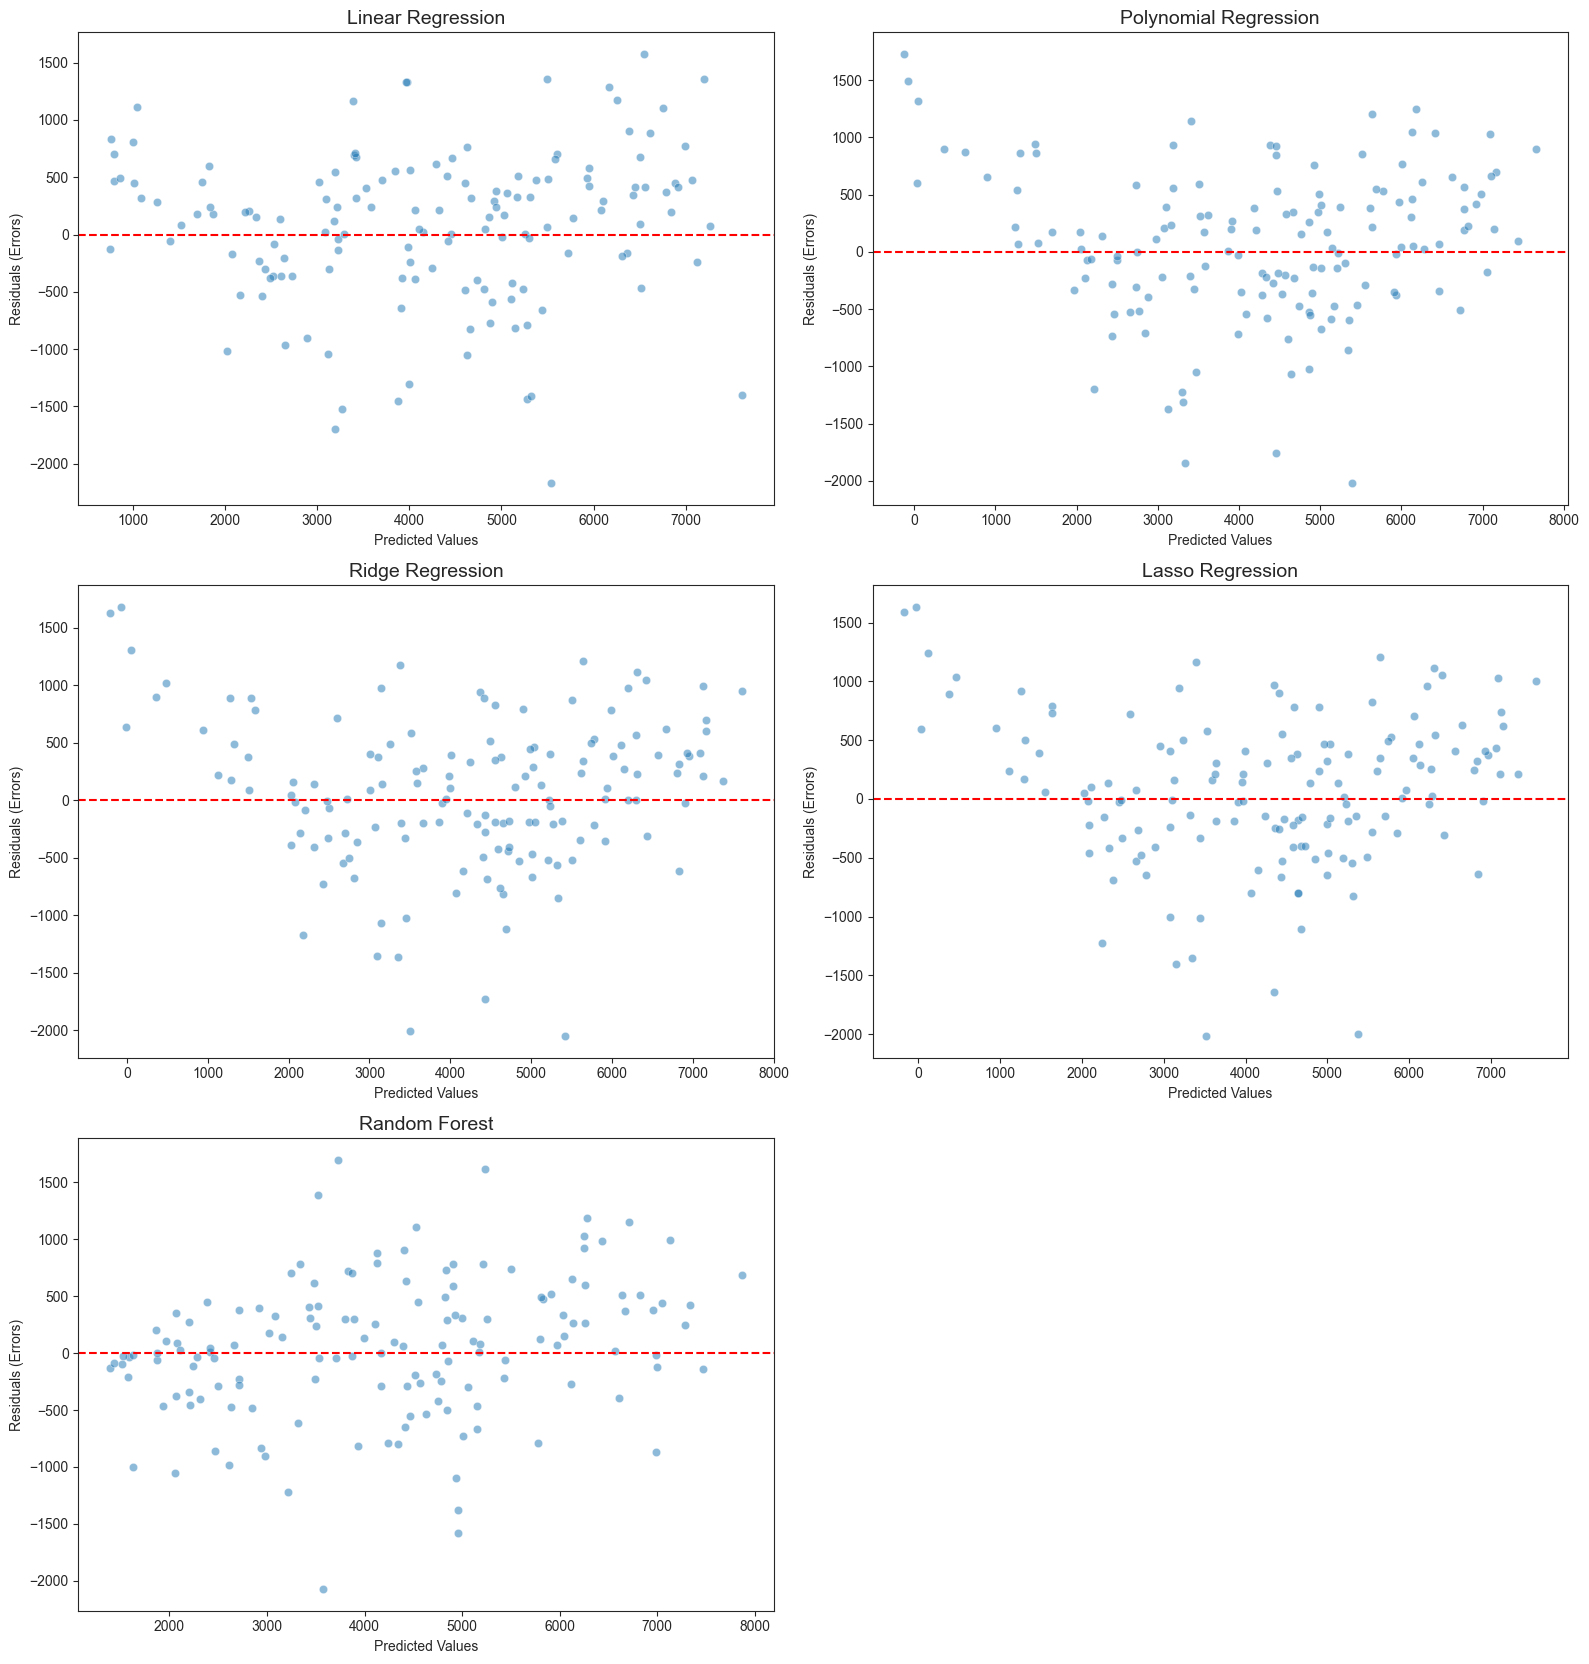

#### **Figure 23:** Residual Analysis: Errors vs. Predicted Values

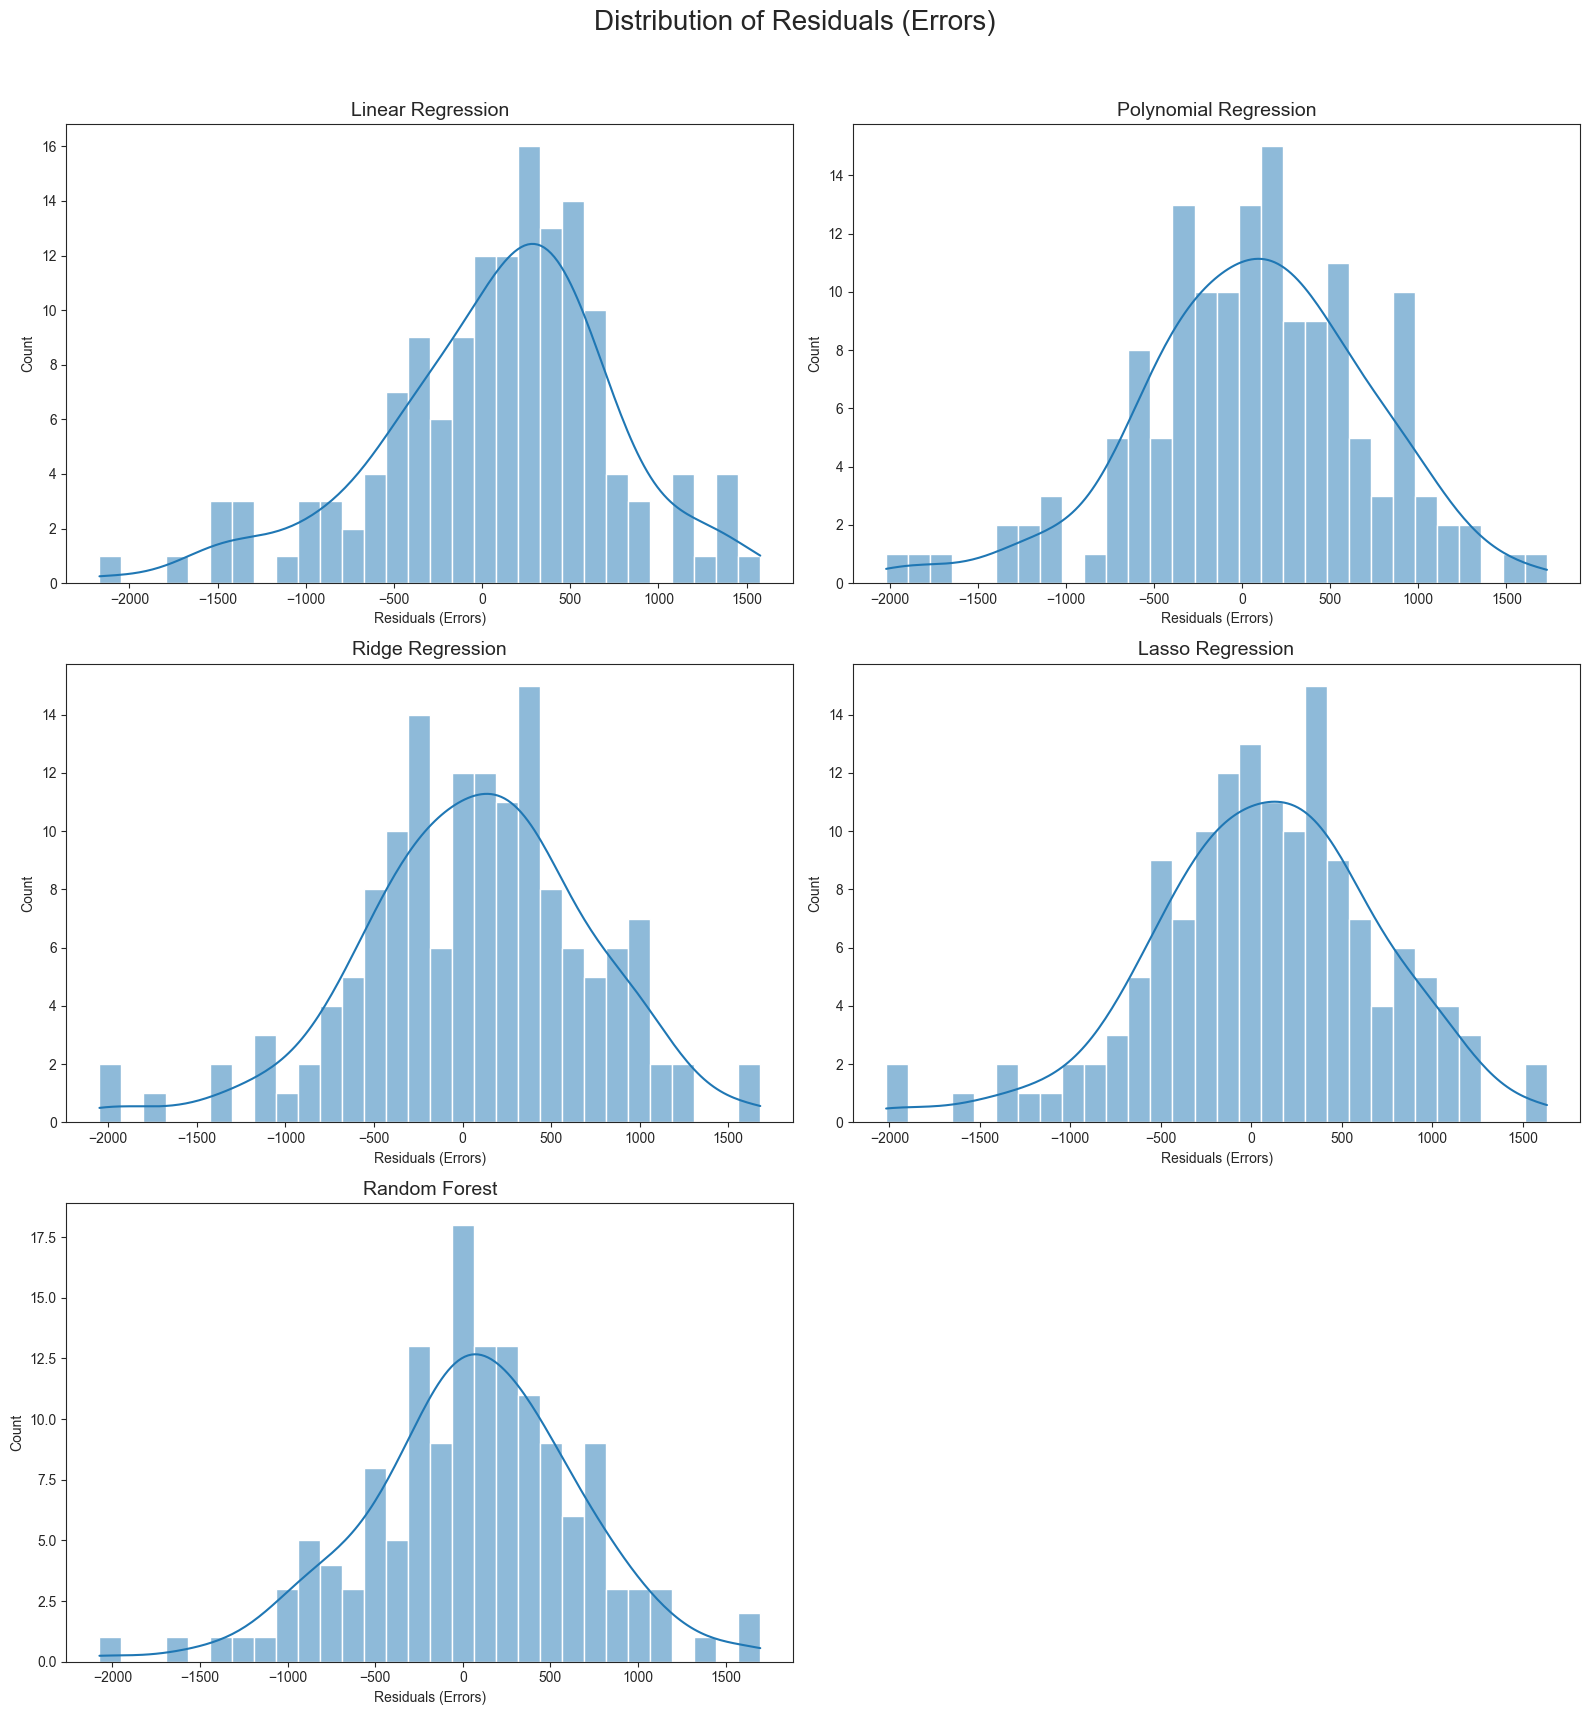

#### **Figure 24:** Distribution of Residuals (Errors)

In [294]:

# --- 1. Collect results from all models ---

# The final trained models and test data are available in memory.
# We use a unified test dataset for a fair comparison.
X_test_final = X_test_rf  # or X_test_lasso, etc. - they should be identical
y_test_final = y_test_rf

# Create a dictionary with the final trained models
models = {
    "Linear Regression": final_pipeline_linear, # From Forward Selection
    "Polynomial Regression": final_pipeline_poly,
    "Ridge Regression": final_ridge_pipeline,
    "Lasso Regression": final_lasso_pipeline,
    "Random Forest": final_rf_model
}

# Create a DataFrame to store predictions
predictions_df = pd.DataFrame({'Actual': y_test_final})

# Make predictions for each model and add them to the DataFrame
for name, model in models.items():
    predictions_df[name] = model.predict(X_test_final)

#display(predictions_df.head())


# --- 2. Calculate and compare numeric metrics ---

metrics_data = []
for name in models.keys():
    mse = mean_squared_error(predictions_df['Actual'], predictions_df[name])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(predictions_df['Actual'], predictions_df[name])
    r2 = r2_score(predictions_df['Actual'], predictions_df[name])
    metrics_data.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R-squared (R²)': r2
    })

metrics_df = pd.DataFrame(metrics_data)
#print("\n--- Comparison of Model Metrics ---")
#(metrics_df)


# --- 3. Visualization of metrics ---

print("--- Visual Comparison of Model Metrics ---")
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

# Plot RMSE and MAE
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Value', hue='Metric',
            data=metrics_melted[metrics_melted['Metric'].isin(['RMSE', 'MAE'])],
            palette='Blues_r')
#plt.title('Comparison of Model Errors (RMSE & MAE)', fontsize=16)
plt.ylabel('Error Value (Number of Rentals)')
plt.xticks(rotation=15)
plt.show()
display(Markdown("#### **Figure 21:** Comparison of Model Errors (RMSE & MAE)"))

# Plot R-squared
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Value', hue='Model', legend=False,
            data=metrics_melted[metrics_melted['Metric'] == 'R-squared (R²)'],
            palette='Blues')
plt.title('Comparison of R-squared (R²)', fontsize=16)
plt.ylabel('R² Value')
plt.ylim(0.8, 1) # Zoom in on the top performers
plt.xticks(rotation=15)
plt.show()
display(Markdown("#### **Figure 22:** Comparison of R-squared (R²)"))

# --- 4. Residual analysis visualization (error analysis) ---

# Calculate residuals for each model
for name in models.keys():
    predictions_df[f'{name}_Residuals'] = predictions_df['Actual'] - predictions_df[name]

# Plot residuals against predicted values
# This helps detect patterns in errors (e.g., whether the model performs worse at high values)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()
#fig.suptitle('Residual Analysis: Errors vs. Predicted Values', fontsize=20)

for i, name in enumerate(models.keys()):
    sns.scatterplot(x=predictions_df[name], y=predictions_df[f'{name}_Residuals'], ax=axes[i], alpha=0.5)
    axes[i].axhline(0, ls='--', color='red')
    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel('Predicted Values')
    axes[i].set_ylabel('Residuals (Errors)')

# Hide any unused subplots
if len(models) < len(axes):
    for i in range(len(models), len(axes)):
        axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()
display(Markdown("#### **Figure 23:** Residual Analysis: Errors vs. Predicted Values"))


# Plot distribution of residuals
# A good model should have errors that are normally distributed around zero.
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()
fig.suptitle('Distribution of Residuals (Errors)', fontsize=20)

for i, name in enumerate(models.keys()):
    sns.histplot(predictions_df[f'{name}_Residuals'], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel('Residuals (Errors)')

# Hide any unused subplots
if len(models) < len(axes):
    for i in range(len(models), len(axes)):
        axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()
display(Markdown("#### **Figure 24:** Distribution of Residuals (Errors)"))

The initial comparison focuses on the predictive accuracy of each model on the test set. The results clearly establish a superior model for this task. The Random Forest model stands out as the top performer across all key metrics (see Figure 21 and 22).
It achieves the highest **R-squared (R²) of 0.895**, indicating it was the most successful at explaining the variance in daily bike rentals. Furthermore, it also has the lowest error rates, with an **RMSE of 611.22** and an **MAE of 466.89**. This means its predictions, on average, have the smallest error in terms of the number of bikes rented.
The other four models, including the Polynomial Regression, Lasso, Ridge, and the baseline Linear Regression, all form a second tier with very similar and slightly lower performance, each achieving an R-squared value of approximately 0.88. The clear superiority of the Random Forest suggests that its ability to natively capture complex, non-linear patterns provides a significant advantage for this dataset.

A comparative analysis of the model residuals provides deeper insights into their behavior. The plots of residuals versus predicted values reveal that all models exhibit some degree of heteroscedasticity, as the error variance tends to increase with higher predicted rental counts. While the Polynomial Regression improves upon the simple linear model by reducing some systematic patterns, the Random Forest produces the most random scatter, indicating it most effectively captured the data's underlying non-linearities.

The error distributions, visualized in the histograms, further distinguish the models. All models produce errors that are roughly bell-shaped and centered around zero, suggesting no major systematic bias. However, the Random Forest's residuals are the most tightly clustered around zero with the thinnest tails, confirming it produces the most consistent and least extreme errors. In contrast, the linear and polynomial models exhibit wider error distributions. In summary, while no model is perfect, the residual analysis confirms that the Random Forest is the most statistically robust, consistently yielding more concentrated and symmetric errors than the other approaches.

In the third part of our comparison, we shift our focus from predictive accuracy to the internal logic of the models. The goal is to understand which features each model actually uses and how heavily it weights them. This analysis provides insight into the different ways the algorithms solve the prediction problem.

The process begins by identifying the set of "selected" or most relevant features for each of the five models. For the Linear and Polynomial regressions, this set is determined by the forward selection process. In the case of Lasso, GridSearchCV finds the optimal regularization strength (alpha) which in turn determines the final set of features with non-zero coefficients. The Ridge model, by contrast, does not perform feature selection and retains all predictors, therefore it is not included in this particular feature selection comparison. Finally, for the Random Forest, we consider the top 25 features as ranked by their Gini importance scores.

To create a more nuanced comparison, we then quantify the relative importance of these features. For the linear-based models (Linear, Polynomial, Ridge, and Lasso), importance is measured by the absolute value of the final coefficients. For the Random Forest, we use its native feature_importances_. These importance values are collected into a single DataFrame, pivoted, and then normalized on a per-model basis to a 0-1 scale for a fair comparison. To keep the final visualization clear and impactful, the data is filtered to show only those features with a high relative importance in at least one model. The result is a color-coded heatmap that instantly reveals which predictors carry consistent weight across every algorithm and which ones each model favors uniquely.


--- Visual Comparison of Features Used by Each Model ---


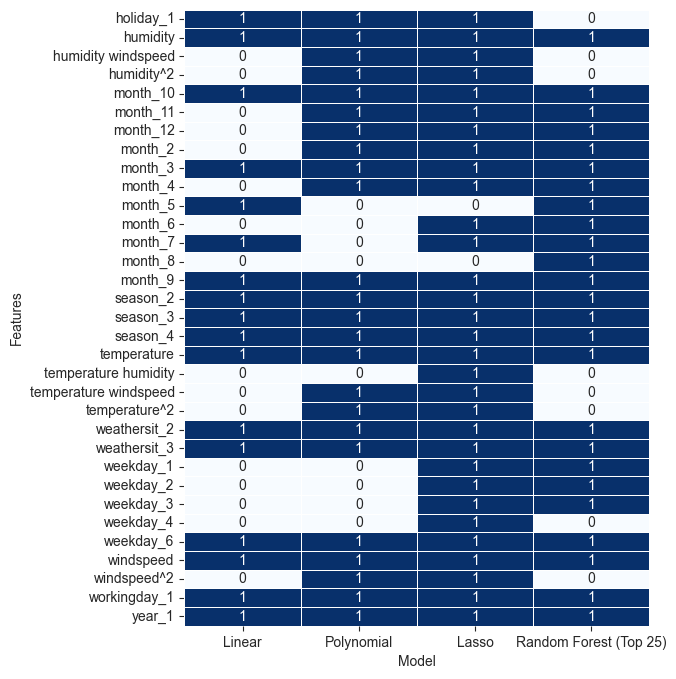

#### **Figure 25:** Feature Selection Comparison Across Models


--- Comparing Feature Importances Across Models ---


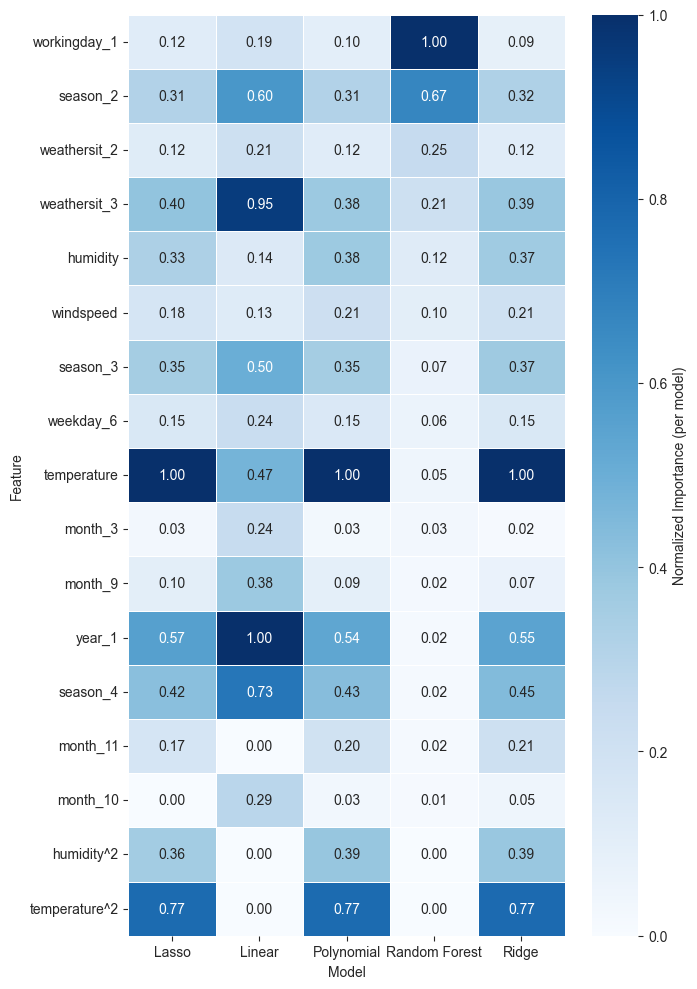

#### **Figure 26:** Normalized Feature Importance Comparison Across Models

In [295]:
# --- 5. Visual Comparison of Selected Features ---

print("\n--- Visual Comparison of Features Used by Each Model ---")

# Get feature names for each model
# Linear and Poly (from stepwise selection)
linear_feats = set(best_features_linear)
poly_feats = set(best_features_poly)

# Lasso (features with non-zero coefficients)
lasso_preprocessor = final_lasso_pipeline.named_steps['preprocessor']
lasso_feature_names = list(lasso_preprocessor.named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_lasso)) + \
                      list(lasso_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features_lasso))
lasso_coefs = final_lasso_pipeline.named_steps['lasso'].coef_
lasso_feats = set(pd.Series(lasso_coefs, index=lasso_feature_names)[lasso_coefs != 0].index)

# Random Forest (top 25 most important features)
rf_preprocessor = final_rf_model.named_steps['preprocessor']
rf_feature_names = final_rf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_rf)
# Note: The remainder='passthrough' puts numerical features at the end
all_rf_features = list(rf_feature_names) + numerical_features_rf 
importances = final_rf_model.named_steps['regressor'].feature_importances_
rf_feats = set(pd.Series(importances, index=all_rf_features).sort_values(ascending=False).head(25).index)


# Create a comparison DataFrame
all_features = sorted(list(linear_feats | poly_feats | lasso_feats | rf_feats))
feature_comparison_df = pd.DataFrame(index=all_features)

feature_comparison_df['Linear'] = [1 if feat in linear_feats else 0 for feat in all_features]
feature_comparison_df['Polynomial'] = [1 if feat in poly_feats else 0 for feat in all_features]
feature_comparison_df['Lasso'] = [1 if feat in lasso_feats else 0 for feat in all_features]
feature_comparison_df['Random Forest (Top 25)'] = [1 if feat in rf_feats else 0 for feat in all_features]

# Generate the heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(feature_comparison_df, cmap="Blues", annot=True, cbar=False, linewidths=.5)
#plt.title('Feature Selection Comparison Across Models', fontsize=16)
plt.xlabel('Model')
plt.ylabel('Features')
plt.show()
display(Markdown("#### **Figure 25:** Feature Selection Comparison Across Models"))


# --- 6. Extract and Compare Feature Importances ---

print("\n--- Comparing Feature Importances Across Models ---")
importance_data = []

# Model 1: Linear Regression (from Forward Selection)
linear_coefs = final_pipeline_linear.named_steps['regressor'].coef_
for feature, coef in zip(best_features_linear, linear_coefs):
    importance_data.append({'Model': 'Linear', 'Feature': feature, 'Importance': abs(coef)})

# Model 2: Polynomial Regression (from Forward Selection)
poly_coefs = final_pipeline_poly.named_steps['regressor'].coef_
for feature, coef in zip(best_features_poly, poly_coefs):
    importance_data.append({'Model': 'Polynomial', 'Feature': feature, 'Importance': abs(coef)})

# Model 3: Ridge Regression
ridge_preprocessor = final_ridge_pipeline.named_steps['preprocessor']
ridge_poly_names = ridge_preprocessor.named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_ridge)
ridge_ohe_names = ridge_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features_ridge)
ridge_all_features = list(ridge_poly_names) + list(ridge_ohe_names)
ridge_coefs = final_ridge_pipeline.named_steps['ridge'].coef_
for feature, coef in zip(ridge_all_features, ridge_coefs):
    importance_data.append({'Model': 'Ridge', 'Feature': feature, 'Importance': abs(coef)})

# Model 4: Lasso Regression
lasso_preprocessor = final_lasso_pipeline.named_steps['preprocessor']
lasso_poly_names = lasso_preprocessor.named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_lasso)
lasso_ohe_names = lasso_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features_lasso)
lasso_all_features = list(lasso_poly_names) + list(lasso_ohe_names)
lasso_coefs = final_lasso_pipeline.named_steps['lasso'].coef_
for feature, coef in zip(lasso_all_features, lasso_coefs):
    if abs(coef) > 0: # Only include non-zero coefficients
        importance_data.append({'Model': 'Lasso', 'Feature': feature, 'Importance': abs(coef)})

# Model 5: Random Forest
rf_preprocessor = final_rf_model.named_steps['preprocessor']
rf_ohe_names = rf_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features_rf)
rf_all_features = numerical_features_rf + list(rf_ohe_names) # Order is numerical first, then categorical
rf_importances = final_rf_model.named_steps['regressor'].feature_importances_
for feature, imp in zip(rf_all_features, rf_importances):
    importance_data.append({'Model': 'Random Forest', 'Feature': feature, 'Importance': imp})

# Create a single DataFrame
importance_df = pd.DataFrame(importance_data)


# --- 6. Visualize Feature Importances as a Heatmap ---

# Pivot the data to create a matrix: Features as rows, Models as columns
pivot_df = importance_df.pivot_table(index='Feature', columns='Model', values='Importance', fill_value=0)

# Normalize the importance values for each model to a 0-1 scale for better comparison
pivot_norm = pivot_df.div(pivot_df.max(axis=0), axis=1)

# Filter for features that are important in at least one model to keep the plot readable
top_features = pivot_norm[pivot_norm.max(axis=1) > 0.2].index
pivot_filtered = pivot_norm.loc[top_features]


# Generate the heatmap
plt.figure(figsize=(7, 10))
sns.heatmap(pivot_filtered.sort_values(by='Random Forest', ascending=False),
            cmap="Blues",
            annot=True,
            fmt=".2f",
            linewidths=.5,
            cbar_kws={"label": "Normalized Importance (per model)"})
#plt.title('Normalized Feature Importance Comparison', fontsize=16)
plt.xlabel('Model')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
display(Markdown("#### **Figure 26:** Normalized Feature Importance Comparison Across Models"))

The feature selection heatmap reveals a core set of indispensable predictors that all models agree on, including temperature, humidity, windspeed, working-day status, the year trend, and the primary season and weather situation categories. Beyond this shared nucleus, however, the models' approaches diverge significantly. The Polynomial Regression model expands its feature set with quadratic and interaction terms like temperature² and temperature × humidity. Interestingly, by adding these non-linear terms, it can drop several monthly indicators that the simpler linear model relies on, suggesting the new polynomial features effectively absorb the variance previously captured by the calendar dummies. The Lasso model takes an intermediate stance, retaining most baseline variables plus a few strong quadratic effects while pruning weaker seasonal terms. In contrast, the Random Forest's list of top features is dominated by first-order variables. Because its tree-based structure captures non-linearity implicitly, the ensemble has no need for explicit polynomial terms, but it does elevate the importance of additional calendar signals like specific weekdays and months that the linear-family models tend to suppress.


When we normalize each model’s importance scores to a 0–1 scale and filter out less influential predictors, temperature emerges as the dominant driver across the board, with a normalized score of 1.00 in Lasso, Polynomial and Ridge, and a still-substantial 0.47 in the simple linear  aber hat einen geringen einfluss bei Random forst. The squared temperature term also ranks very high (0.77) in Lasso, Polynomial, and Ridge, underscoring a clear non-linear temperature effect.  The year dummy shows strong importance (above 0.50) in all models außer bei Random Forest, signaling a systematic upward trend in rentals over time. Among the weather variables, weathersit_3 (likely representing cloudy or drizzly conditions) carries more weight in the linear and polynomial fits than in the tree ensemble, while humidity and its square both contribute moderately in the linear-type models but are less critical in the Random Forest. Season_2 zeigt insbesondere bei random foest eine hohe bedeutung sowie bei der lineare regression. Innteressanterweise ist die wichtigeste Variabel bei rndom forest wirkingday:1 bei den anderen modellen nicht so wichtig. Overall, the heatmap reveals that all linear regrssion models (lin, poly, ridge and lasso) afree on a core set of predictors, wobei temperatur besonders hervorsticht. Bei Random Forest ...

After we scale every model’s importance scores to a 0–1 range and drop the very small ones, a clear picture appears. Temperature is the top factor in all the linear-type models.I t gets the maximum weight in Lasso, Polynomial and Ridge and still holds almost half of the weight in simple linear regression. In the Random Forest, though, temperature matters little. The squared temperature term is also strong in the linear family, showing that bike demand rises in a curved way as it gets warmer. The year variable is important in the linear models but almost ignored by the Random Forest, which spreads the long-term trend across other date splits. Cloudy weather (`weathersit_3`) and humidity matter more to the linear fits than to the forest. Season 2 is picked up strongly by the Random Forest and, to a lesser degree, by linear regression. The biggest gap is for `workingday`, it is the most important feature in the Random Forest yet plays only a small role in the other models. In short, the linear methods agree on a climate-driven core led by temperature, while the Random Forest focuses more on calendar cues such as working days and seasons and captures temperature effects through its tree splits rather than direct weights.


# 5. Conclusion and Future Outlook

## 5.1 Conclusion

In our project, we developed predictive models to estimate daily bike rental counts using historical data from Washington D.C.’s Capital Bikeshare system. To achieve this, we preprocessed and analyzed the data and applied four different regression models:


- **LASSO Regression** achieved the **lowest MSE (322,174)**, **lowest RMSE (567.60)**, **lowest MAE (402.50)**, and the **highest R² score (0.920)**, making it the most accurate model.
  
- **Ridge Regression** performed nearly as well, with **R² score (0.919)** and **RMSE (570.04)**, highlighting the benefit of regularization in managing multicollinearity and improving generalization.
  
- **Random Forest Regression**, while nonlinear and flexible, did not outperform the regularized linear models. Its **R² score (0.910)** and **RMSE (601.36)** were slightly worse.
  
- **Linear Regression** was the least accurate, with the **lowest R² (0.892)** and **highest RMSE (657.62)**, indicating it was too simplistic to capture the complexity of the data.

  

---

## 5.2 Future Work

To further improve model performance and practical utility, the following directions could be considered:

- **Adding more features**  
  Including more information — public events, holidays, or public transport usage — might help the model understand what affects bike rentals        beyond just weather and season.

- **Time-based modeling**  
  Bike rentals are highly seasonal and follow daily or weekly patterns. Using time series models like ARIMA, Prophet, or even simple moving averages could help capture those trends better.

- **Real-Time Prediction**  
  Integrate live weather and traffic feeds to enable dynamic, on-the-fly forecasting.

- **Deployment & Visualization**  
  Develop a user-friendly dashboard or API to support decision-making by city planners or bikeshare operators.



# 6. Sources

**[1]** Fanaee‑T, H., & Gama, J. (2013). _Event labeling combining ensemble detectors and background knowledge_. Progress in Artificial Intelligence, 1–15. Springer Berlin Heidelberg. https://doi.org/10.1007/s13748-013-0040-3
